In [4]:
pip install keras-tcn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# Cell 1: Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [6]:
# Cell 2: Load the dataset
file_path = "C:/jupyter notebook files/final_project/GlobalWeatherRepository.csv"
df = pd.read_csv(file_path)

# Display the first few rows of the dataset
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [7]:
# Cell 3: Data Preprocessing
# Check for missing values
print(df.isnull().sum())

# Fill missing values if any
df = df.fillna(method='ffill')  # Forward fill missing values

# Convert 'last_updated' column to datetime format
df['last_updated'] = pd.to_datetime(df['last_updated'])

# Set 'last_updated' as the index
df.set_index('last_updated', inplace=True)

# Display the first few rows of the dataframe
df.head()

country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Ni

C:\Users\Sayan\AppData\Local\Temp\ipykernel_4116\382128891.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')  # Forward fill missing values


,country,location_name,latitude,longitude,timezone,last_updated_epoch,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
last_updated,,,,,,,,,,,,,,,,,,,,,
2024-05-16 13:15:00,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,26.6,79.8,Partly Cloudy,8.3,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
2024-05-16 10:45:00,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,19.0,66.2,Partly cloudy,6.9,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2024-05-16 09:45:00,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,23.0,73.4,Sunny,9.4,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
2024-05-16 10:45:00,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,6.3,43.3,Light drizzle,7.4,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
2024-05-16 09:45:00,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,26.0,78.8,Partly cloudy,8.1,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


           latitude     longitude  last_updated_epoch  temperature_celsius  \
count  47162.000000  47162.000000        4.716200e+04         47162.000000   
mean      19.143012     22.209506        1.726357e+09            23.242977   
std       24.482099     65.783877        6.112758e+06             9.016761   
min      -41.300000   -175.200000        1.715849e+09           -24.800000   
25%        3.750000     -6.250000        1.720963e+09            18.400000   
50%       17.250000     23.320000        1.726402e+09            25.400000   
75%       40.400000     50.580000        1.731661e+09            29.000000   
max       64.150000    179.220000        1.736855e+09            49.200000   

       temperature_fahrenheit      wind_mph      wind_kph   wind_degree  \
count            47162.000000  47162.000000  47162.000000  47162.000000   
mean                73.838777      8.305225     13.369927    171.318010   
std                 16.230117      9.991996     16.079441    103.029295 

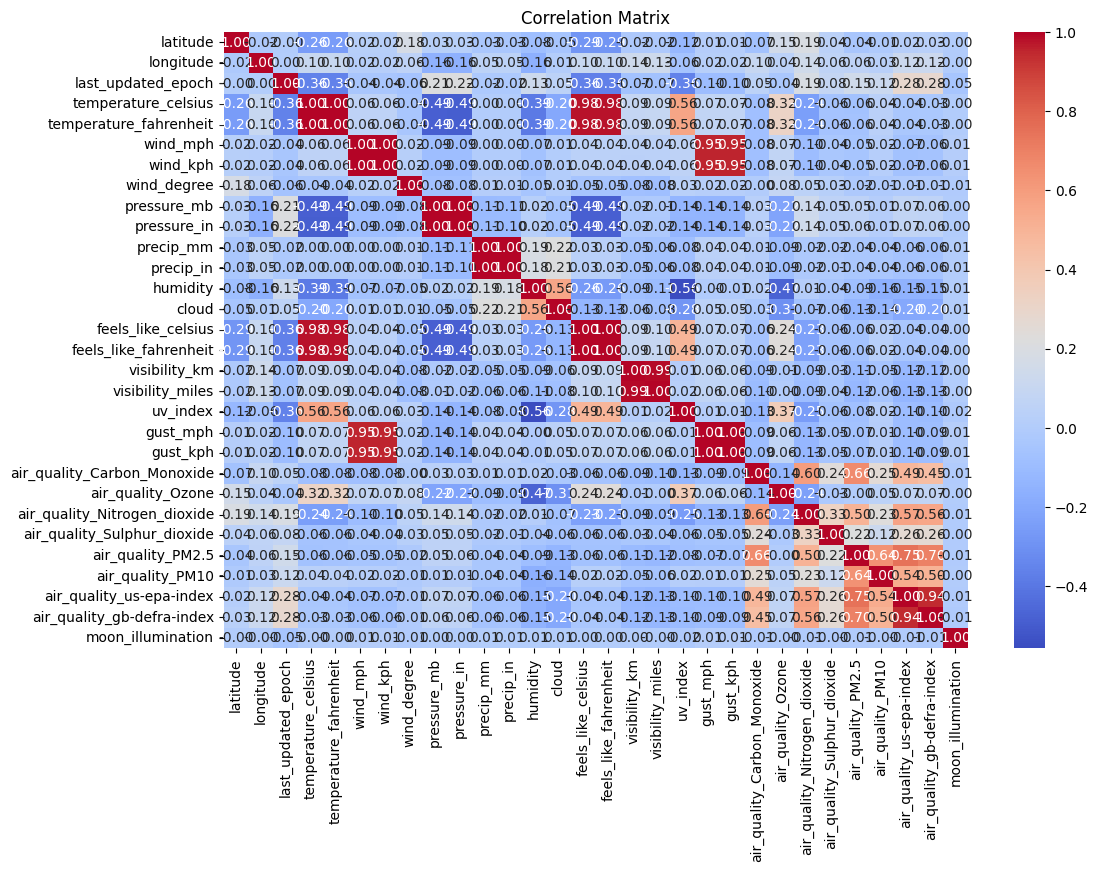

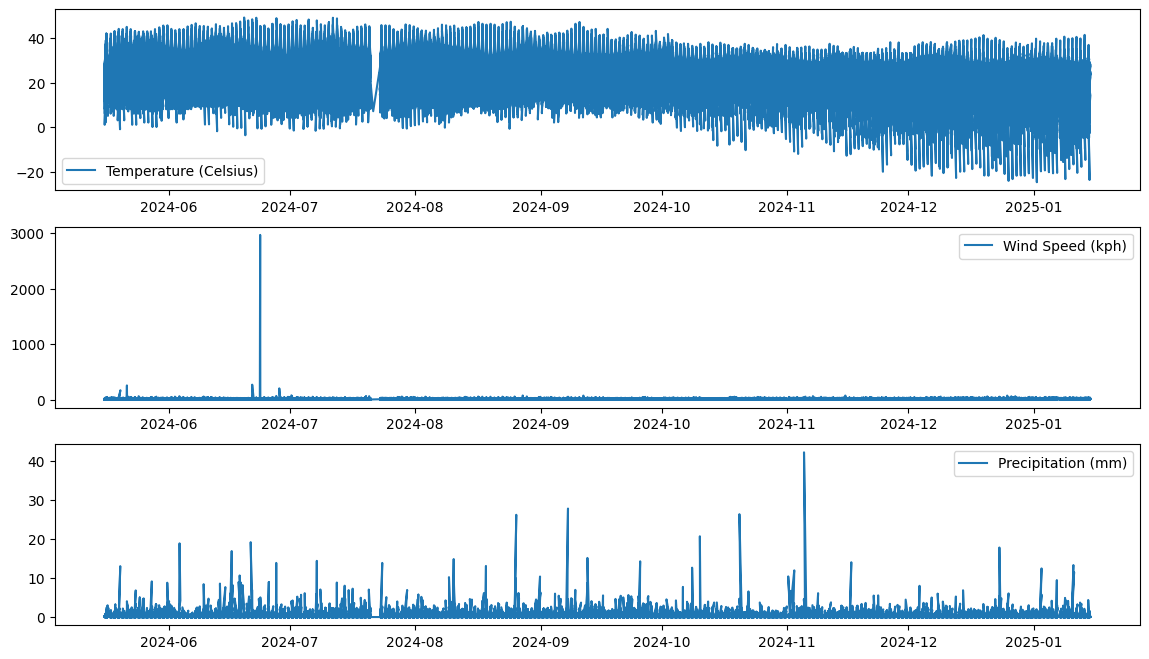

In [8]:
# Cell 4: Exploratory Data Analysis (EDA)
# Summary statistics
print(df.describe())

# Correlation matrix for numerical columns
numerical_columns = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numerical_columns].corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Plotting the target variables over time
plt.figure(figsize=(14, 8))
plt.subplot(3, 1, 1)
plt.plot(df['temperature_celsius'], label='Temperature (Celsius)')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(df['wind_kph'], label='Wind Speed (kph)')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(df['precip_mm'], label='Precipitation (mm)')
plt.legend()

plt.show()

In [9]:
# Cell 5: Feature Scaling
# Select only numerical columns for scaling
numerical_columns = df.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

# Display the first few rows of the scaled dataframe
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
last_updated,,,,,,,,,,,,,,,,,,,,,
2024-05-16 13:15:00,Afghanistan,Kabul,0.628098,0.714020,Asia/Kabul,-1.718954,0.372313,0.367298,Partly Cloudy,-0.000523,...,-0.320178,-0.136402,-0.666440,-0.602478,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,0.175557
2024-05-16 10:45:00,Albania,Tirana,0.906263,-0.036324,Europe/Tirane,-1.718954,-0.470571,-0.470659,Partly cloudy,-0.140637,...,-0.479613,-0.314849,-0.666440,-0.602478,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,0.175557
2024-05-16 09:45:00,Algeria,Algiers,0.719594,-0.291252,Africa/Algiers,-1.718954,-0.026948,-0.027035,Sunny,0.109566,...,-0.276497,-0.195884,-0.666440,-0.602478,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,0.175557
2024-05-16 10:45:00,Andorra,Andorra La Vella,0.954054,-0.314511,Europe/Andorra,-1.718954,-1.879074,-1.881632,Light drizzle,-0.090596,...,-0.488350,-0.322828,-0.666440,-0.602478,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,0.175557
2024-05-16 09:45:00,Angola,Luanda,-1.143011,-0.136502,Africa/Luanda,-1.718954,0.305770,0.305683,Partly cloudy,-0.020539,...,3.501900,1.573352,3.543677,3.097057,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,0.175557


In [10]:
# Cell 6: Prepare Data for TCN
def create_sequences(data, seq_length, pred_length):
    X, y = [], []
    for i in range(len(data) - seq_length - pred_length):
        X.append(data.iloc[i:i+seq_length][numerical_columns].values)
        y.append(data.iloc[i+seq_length:i+seq_length+pred_length][['temperature_celsius', 'wind_kph', 'precip_mm']].values)
    return np.array(X), np.array(y)

seq_length = 30  # Number of time steps to look back
pred_length = 7  # Number of time steps to predict

X, y = create_sequences(df, seq_length, pred_length)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(37700, 30, 30) (9425, 30, 30) (37700, 7, 3) (9425, 7, 3)


In [11]:
# Cell 7: Build the TCN Model
from tensorflow.keras.layers import Reshape

def build_tcn_model(input_shape):
    model = Sequential()
    
    # Convolutional layers
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())
    
    # Fully connected layers
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu'))
    
    # Output layer
    model.add(Dense(pred_length * 3))  # Output shape: (batch_size, 21)
    
    # Reshape the output to match the target shape (batch_size, 7, 3)
    model.add(Reshape((pred_length, 3)))  # Output shape: (batch_size, 7, 3)
    
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    
    return model

input_shape = (X_train.shape[1], X_train.shape[2])
model = build_tcn_model(input_shape)
model.summary()

C:\Users\Sayan\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 28, 64)              │           5,824 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 14, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 12, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 6, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 768)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          98,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 21)                  │           1,365 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 7, 3)                │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 138,581 (541.33 KB)

 Trainable params: 138,581 (541.33 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.9833 - val_loss: 0.8306
Epoch 2/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.9401 - val_loss: 0.7530
Epoch 3/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.8281 - val_loss: 0.6929
Epoch 4/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.9726 - val_loss: 0.6731
Epoch 5/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.7178 - val_loss: 0.6635
Epoch 6/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.6068 - val_loss: 0.6589
Epoch 7/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.8180 - val_loss: 0.6558
Epoch 8/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.6551 - val_loss: 0.6568
Epoch 9/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.7835 - val_loss: 0.6521
Epoch 10/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.7237 - val_loss: 0.6694
Epoch 11/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.6713 - val_loss: 0.6843
Epoch 12/100
943/943 ━━━━━━━━━━━━━━━━━━━━

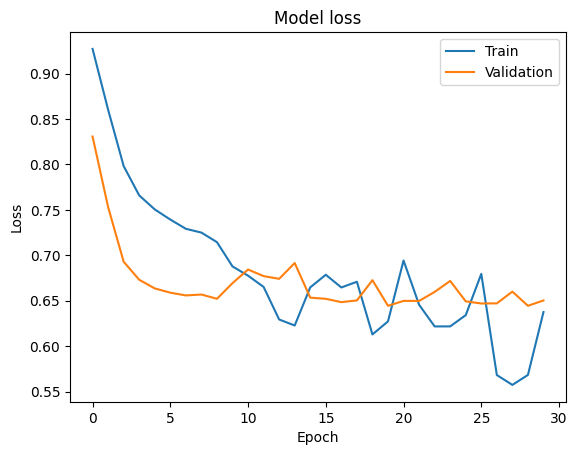

In [12]:
# Cell 8: Train the Model
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping]
)

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

In [13]:
# Cell 9: Evaluate the Model
y_pred = model.predict(X_test)

# Reshape y_test and y_pred for metric calculation
y_test_reshaped = y_test.reshape(-1, 3)  # Shape: (batch_size * 7, 3)
y_pred_reshaped = y_pred.reshape(-1, 3)  # Shape: (batch_size * 7, 3)

# Calculate overall metrics
rmse = np.sqrt(mean_squared_error(y_test_reshaped, y_pred_reshaped))
mse = mean_squared_error(y_test_reshaped, y_pred_reshaped)
mae = mean_absolute_error(y_test_reshaped, y_pred_reshaped)
r2 = r2_score(y_test_reshaped, y_pred_reshaped)

print(f'Overall Metrics:')
print(f'RMSE: {rmse}')
print(f'MSE: {mse}')
print(f'MAE: {mae}')
print(f'R²: {r2}')

# Individual metrics for each parameter
for i, param in enumerate(['temperature_celsius', 'wind_kph', 'precip_mm']):
    # Calculate metrics for each parameter
    rmse_param = np.sqrt(mean_squared_error(y_test_reshaped[:, i], y_pred_reshaped[:, i]))
    mse_param = mean_squared_error(y_test_reshaped[:, i], y_pred_reshaped[:, i])
    mae_param = mean_absolute_error(y_test_reshaped[:, i], y_pred_reshaped[:, i])
    r2_param = r2_score(y_test_reshaped[:, i], y_pred_reshaped[:, i])
    
    # Print metrics for the parameter
    print(f'\n{param} Metrics:')
    print(f'RMSE: {rmse_param}')
    print(f'MSE: {mse_param}')
    print(f'MAE: {mae_param}')
    print(f'R²: {r2_param}')

295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Overall Metrics:
RMSE: 0.9025520199341898
MSE: 0.8146001486872861
MAE: 0.35034503619285934
R²: 0.2881777417694134

temperature_celsius Metrics:
RMSE: 0.44367306289104974
MSE: 0.19684578673512537
MAE: 0.33168664351536303
R²: 0.8031119862178421

wind_kph Metrics:
RMSE: 1.1270911345214087
MSE: 1.2703344255167563
MAE: 0.36800922034096856
R²: 0.0338570983334322

precip_mm Metrics:
RMSE: 0.9882409796248818
MSE: 0.9766202338099459
MAE: 0.3513392447219968
R²: 0.027564140756454525


In [14]:
# Cell 11: Hyperparameter Tuning with Keras Tuner
import keras_tuner as kt

def build_tcn_model(hp):
    model = Sequential()
    
    # Tunable number of filters
    filters = hp.Int('filters', min_value=32, max_value=256, step=32)
    
    # Tunable kernel size
    kernel_size = hp.Int('kernel_size', min_value=2, max_value=5, step=1)
    
    # Tunable number of convolutional layers
    num_layers = hp.Int('num_layers', min_value=1, max_value=4, step=1)
    
    # Tunable dropout rate
    dropout_rate = hp.Float('dropout_rate', min_value=0.1, max_value=0.5, step=0.1)
    
    # Tunable learning rate
    learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    
    # Add convolutional layers
    for i in range(num_layers):
        model.add(Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            activation='relu',
            padding='same',
            input_shape=(X_train.shape[1], X_train.shape[2]) if i == 0 else None
        ))
        model.add(MaxPooling1D(pool_size=2))
    
    # Flatten and add dense layers
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(64, activation='relu'))
    
    # Output layer
    model.add(Dense(pred_length * 3))  # Output shape: (batch_size, 21)
    model.add(Reshape((pred_length, 3)))  # Reshape to match target shape
    
    # Compile the model
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mse'
    )
    
    return model

# Initialize the tuner
tuner = kt.RandomSearch(
    build_tcn_model,
    objective='val_loss',
    max_trials=10,  # Number of hyperparameter combinations to try
    executions_per_trial=1,
    directory='tuner_results1',
    project_name='tcn_weather_forecasting'
)

# Perform hyperparameter search
tuner.search(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5)]
)

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"""
Best Hyperparameters:
- Filters: {best_hps.get('filters')}
- Kernel Size: {best_hps.get('kernel_size')}
- Number of Layers: {best_hps.get('num_layers')}
- Dropout Rate: {best_hps.get('dropout_rate')}
- Learning Rate: {best_hps.get('learning_rate')}
""")

Trial 10 Complete [00h 02m 05s]
val_loss: 0.6320592164993286

Best val_loss So Far: 0.61929851770401
Total elapsed time: 00h 25m 05s

Best Hyperparameters:
- Filters: 192
- Kernel Size: 5
- Number of Layers: 3
- Dropout Rate: 0.2
- Learning Rate: 0.0001



Epoch 1/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 0.8235 - val_loss: 0.8437
Epoch 2/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.8697 - val_loss: 0.7656
Epoch 3/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.7452 - val_loss: 0.7138
Epoch 4/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.7592 - val_loss: 0.6790
Epoch 5/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.6661 - val_loss: 0.6560
Epoch 6/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.7602 - val_loss: 0.6471
Epoch 7/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.5787 - val_loss: 0.6583
Epoch 8/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.6119 - val_loss: 0.6350
Epoch 9/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.6102 - val_loss: 0.6295
Epoch 10/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.7067 - val_loss: 0.6263
Epoch 11/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.6822 - val_loss: 0.6245
Epoch 12/100
943/943 ━

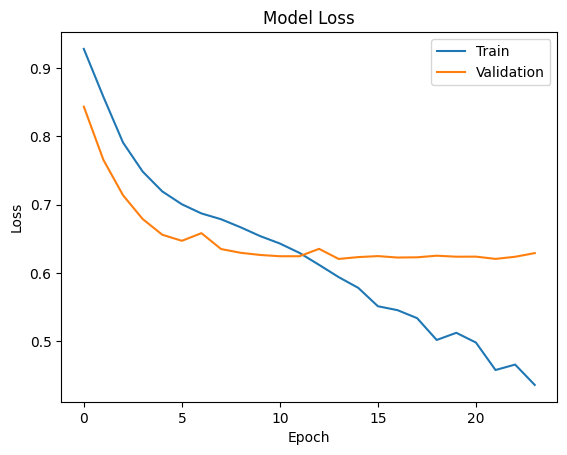

In [15]:
# Cell 12: Train the Model with Best Hyperparameters
# Build the model with the best hyperparameters
model = tuner.hypermodel.build(best_hps)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10)]
)

# Plot training & validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

In [16]:
# Cell 13: Evaluate the Improved Model
y_pred = model.predict(X_test)

# Reshape y_test and y_pred for metric calculation
y_test_reshaped = y_test.reshape(-1, 3)
y_pred_reshaped = y_pred.reshape(-1, 3)

# Calculate overall metrics
rmse = np.sqrt(mean_squared_error(y_test_reshaped, y_pred_reshaped))
mse = mean_squared_error(y_test_reshaped, y_pred_reshaped)
mae = mean_absolute_error(y_test_reshaped, y_pred_reshaped)
r2 = r2_score(y_test_reshaped, y_pred_reshaped)

print(f'Overall Metrics:')
print(f'RMSE: {rmse}')
print(f'MSE: {mse}')
print(f'MAE: {mae}')
print(f'R²: {r2}')

# Individual metrics for each parameter
for i, param in enumerate(['temperature_celsius', 'wind_kph', 'precip_mm']):
    rmse_param = np.sqrt(mean_squared_error(y_test_reshaped[:, i], y_pred_reshaped[:, i]))
    mse_param = mean_squared_error(y_test_reshaped[:, i], y_pred_reshaped[:, i])
    mae_param = mean_absolute_error(y_test_reshaped[:, i], y_pred_reshaped[:, i])
    r2_param = r2_score(y_test_reshaped[:, i], y_pred_reshaped[:, i])
    
    print(f'\n{param} Metrics:')
    print(f'RMSE: {rmse_param}')
    print(f'MSE: {mse_param}')
    print(f'MAE: {mae_param}')
    print(f'R²: {r2_param}')

295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Overall Metrics:
RMSE: 0.9000622314930385
MSE: 0.810112020560228
MAE: 0.33966979338762376
R²: 0.29524279276813764

temperature_celsius Metrics:
RMSE: 0.44724174913410103
MSE: 0.20002518216853016
MAE: 0.33197147440581737
R²: 0.7999319087455544

wind_kph Metrics:
RMSE: 1.1417150264477358
MSE: 1.3035132016165543
MAE: 0.3552840949017897
R²: 0.008623239932905702

precip_mm Metrics:
RMSE: 0.9627033176922313
MSE: 0.9267976778956293
MAE: 0.331753810855117
R²: 0.07717322962535922


In [17]:
# Cell 14: Feature Engineering
# Check available columns in the dataset
print(df.columns)

# If additional features are available, include them in the model
# Example: Add humidity, pressure, and wind direction if available
# df = df[['temperature_celsius', 'wind_kph', 'precip_mm', 'humidity', 'pressure', 'wind_direction']]

# If additional features are not available, create derived features
# Example: Rolling averages, differences, or seasonal indicators
df['temp_rolling_avg'] = df['temperature_celsius'].rolling(window=7).mean()  # 7-day rolling average
df['wind_rolling_avg'] = df['wind_kph'].rolling(window=7).mean()  # 7-day rolling average
df['precip_rolling_avg'] = df['precip_mm'].rolling(window=7).mean()  # 7-day rolling average

# Fill missing values caused by rolling averages
df = df.fillna(method='bfill')

# Display the updated dataframe
df.head()

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'temperature_celsius', 'temperature_fahrenheit',
       'condition_text', 'wind_mph', 'wind_kph', 'wind_degree',
       'wind_direction', 'pressure_mb', 'pressure_in', 'precip_mm',
       'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='object')


C:\Users\Sayan\AppData\Local\Temp\ipykernel_4116\2053939041.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')


,country,location_name,latitude,longitude,timezone,last_updated_epoch,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,...,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,temp_rolling_avg,wind_rolling_avg,precip_rolling_avg
last_updated,,,,,,,,,,,,,,,,,,,,,
2024-05-16 13:15:00,Afghanistan,Kabul,0.628098,0.714020,Asia/Kabul,-1.718954,0.372313,0.367298,Partly Cloudy,-0.000523,...,-0.602478,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,0.175557,-0.440468,-0.146502,-0.136959
2024-05-16 10:45:00,Albania,Tirana,0.906263,-0.036324,Europe/Tirane,-1.718954,-0.470571,-0.470659,Partly cloudy,-0.140637,...,-0.602478,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,0.175557,-0.440468,-0.146502,-0.136959
2024-05-16 09:45:00,Algeria,Algiers,0.719594,-0.291252,Africa/Algiers,-1.718954,-0.026948,-0.027035,Sunny,0.109566,...,-0.602478,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,0.175557,-0.440468,-0.146502,-0.136959
2024-05-16 10:45:00,Andorra,Andorra La Vella,0.954054,-0.314511,Europe/Andorra,-1.718954,-1.879074,-1.881632,Light drizzle,-0.090596,...,-0.602478,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,0.175557,-0.440468,-0.146502,-0.136959
2024-05-16 09:45:00,Angola,Luanda,-1.143011,-0.136502,Africa/Luanda,-1.718954,0.305770,0.305683,Partly cloudy,-0.020539,...,3.097057,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,0.175557,-0.440468,-0.146502,-0.136959


In [18]:
# Cell 15: Update Data Preparation
def create_sequences(data, seq_length, pred_length):
    X, y = [], []
    for i in range(len(data) - seq_length - pred_length):
        # Extract sequences for input (X) and target (y)
        X.append(data[i:i+seq_length])  # Input sequence
        y.append(data[i+seq_length:i+seq_length+pred_length, :3])  # Target sequence (only the first 3 columns: temperature, wind, precipitation)
    return np.array(X), np.array(y)

# Select only numerical columns for scaling
numerical_columns = df.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

# Prepare sequences with the updated features
X, y = create_sequences(df[numerical_columns].values, seq_length, pred_length)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(37700, 30, 33) (9425, 30, 33) (37700, 7, 3) (9425, 7, 3)


In [21]:
# Cell 16: Improved TCN Model with Dilated Convolutions and Residual Connections
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, Dense, Dropout, Reshape
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.layers import Add, Activation, GlobalAveragePooling1D

def build_improved_tcn_model(input_shape):
    inputs = Input(shape=input_shape)
    
    # Initial convolution to match dimensions
    x = Conv1D(filters=128, kernel_size=1, padding='same')(inputs)
    
    # Dilated convolutional layers with residual connections
    for i in range(3):  # Number of TCN blocks
        # First convolution in the block
        conv1 = Conv1D(
            filters=128,
            kernel_size=3,
            dilation_rate=2 ** i,  # Exponential increase in dilation rate
            padding='same',
            activation='relu'
        )(x)
        
        # Second convolution in the block
        conv2 = Conv1D(
            filters=128,
            kernel_size=3,
            dilation_rate=2 ** i,
            padding='same',
            activation='relu'
        )(conv1)
        
        # Residual connection
        if i == 0:
            residual = Conv1D(filters=128, kernel_size=1, padding='same')(inputs)
        else:
            residual = x
        
        # Add residual connection
        x = Add()([conv2, residual])
        x = Activation('relu')(x)
    
    # Global average pooling
    x = GlobalAveragePooling1D()(x)
    
    # Fully connected layers
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu')(x)
    
    # Output layer
    outputs = Dense(pred_length * 3)(x)
    outputs = Reshape((pred_length, 3))(outputs)
    
    # Create the model
    model = tf.keras.Model(inputs, outputs)
    
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    
    return model

input_shape = (X_train.shape[1], X_train.shape[2])
improved_model = build_improved_tcn_model(input_shape)
improved_model.summary()

Model: "functional_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)    │ (None, 30, 33)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_22 (Conv1D)            │ (None, 30, 128)           │           4,352 │ input_layer_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_23 (Conv1D)            │ (None, 30, 128)           │          49,280 │ conv1d_22[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_24 (Conv1D)            │ (None, 30, 128)           │          49,280 │ conv1d_23[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_25 (Conv1D)            │ (None, 30, 128)           │           4,352 │ input_layer_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_6 (Add)                   │ (None, 30, 128)           │               0 │ conv1d_24[0][0],           │
│                               │                           │                 │ conv1d_25[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_6 (Activation)     │ (None, 30, 128)           │               0 │ add_6[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_26 (Conv1D)            │ (None, 30, 128)           │          49,280 │ activation_6[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_27 (Conv1D)            │ (None, 30, 128)           │          49,280 │ conv1d_26[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_7 (Add)                   │ (None, 30, 128)           │               0 │ conv1d_27[0][0],           │
│                               │                           │                 │ activation_6[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_7 (Activation)     │ (None, 30, 128)           │               0 │ add_7[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_28 (Conv1D)            │ (None, 30, 128)           │          49,280 │ activation_7[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_29 (Conv1D)            │ (None, 30, 128)           │          49,280 │ conv1d_28[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_8 (Add)                   │ (None, 30, 128)           │               0 │ conv1d_29[0][0],           │
│                               │                           │                 │ activation_7[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_8 (Activation)     │ (None, 30, 128)           │               0 │ add_8[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling1d_2    │ (None, 128)               │               

 Total params: 330,517 (1.26 MB)

 Trainable params: 330,517 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - loss: 0.7246 - val_loss: 0.6330
Epoch 2/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - loss: 0.6367 - val_loss: 0.5469
Epoch 3/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - loss: 0.5448 - val_loss: 0.4076
Epoch 4/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - loss: 0.4488 - val_loss: 0.2937
Epoch 5/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - loss: 0.3576 - val_loss: 0.2135
Epoch 6/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - loss: 0.3017 - val_loss: 0.1775
Epoch 7/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - loss: 0.2654 - val_loss: 0.1622
Epoch 8/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - loss: 0.2453 - val_loss: 0.1458
Epoch 9/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - loss: 0.2267 - val_loss: 0.1475
Epoch 10/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - loss: 0.2134 - val_loss: 0.1473
Epoch 11/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - loss: 0.2077 - val_loss: 0.1341
Epoch 12/100
943/94

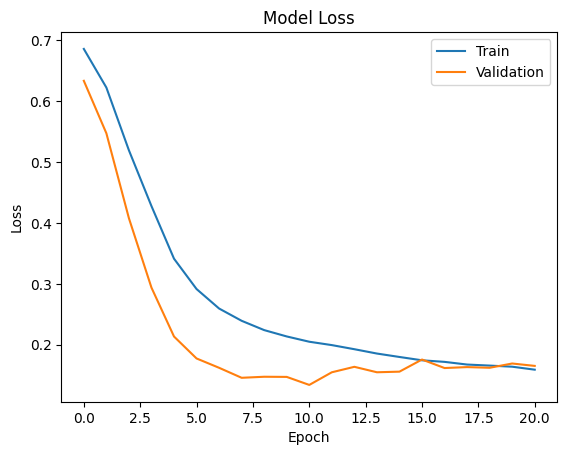

In [22]:
# Cell 17: Train the Improved Model
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = improved_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping]
)

# Plot training & validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

In [23]:
# Cell 18: Evaluate the Improved Model
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    # Reshape y_test and y_pred for metric calculation
    y_test_reshaped = y_test.reshape(-1, 3)
    y_pred_reshaped = y_pred.reshape(-1, 3)
    
    # Calculate overall metrics
    rmse = np.sqrt(mean_squared_error(y_test_reshaped, y_pred_reshaped))
    mse = mean_squared_error(y_test_reshaped, y_pred_reshaped)
    mae = mean_absolute_error(y_test_reshaped, y_pred_reshaped)
    r2 = r2_score(y_test_reshaped, y_pred_reshaped)
    
    print(f'Overall Metrics:')
    print(f'RMSE: {rmse}')
    print(f'MSE: {mse}')
    print(f'MAE: {mae}')
    print(f'R²: {r2}')
    
    # Individual metrics for each parameter
    for i, param in enumerate(['temperature_celsius', 'wind_kph', 'precip_mm']):
        rmse_param = np.sqrt(mean_squared_error(y_test_reshaped[:, i], y_pred_reshaped[:, i]))
        mse_param = mean_squared_error(y_test_reshaped[:, i], y_pred_reshaped[:, i])
        mae_param = mean_absolute_error(y_test_reshaped[:, i], y_pred_reshaped[:, i])
        r2_param = r2_score(y_test_reshaped[:, i], y_pred_reshaped[:, i])
        
        print(f'\n{param} Metrics:')
        print(f'RMSE: {rmse_param}')
        print(f'MSE: {mse_param}')
        print(f'MAE: {mae_param}')
        print(f'R²: {r2_param}')

# Evaluate the improved TCN model
print("Improved TCN Model Evaluation:")
evaluate_model(improved_model, X_test, y_test)

Improved TCN Model Evaluation:
295/295 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Overall Metrics:
RMSE: 0.3706958393421654
MSE: 0.1374154053055925
MAE: 0.2864605541504266
R²: 0.8628292020282228

temperature_celsius Metrics:
RMSE: 0.37963105098835886
MSE: 0.14411973487452592
MAE: 0.2913615200051802
R²: 0.8560820317384024

wind_kph Metrics:
RMSE: 0.3574049061109371
MSE: 0.12773826691216777
MAE: 0.27095803354712406
R²: 0.8724076597318889

precip_mm Metrics:
RMSE: 0.37468415249391446
MSE: 0.14038821413008293
MAE: 0.29706210889896995
R²: 0.8599979146143902


In [24]:
# Cell 22: Save the Improved TCN Model
improved_model.save('improved_tcn_weather_forecasting_model44.h5')
print("Improved TCN model saved successfully.")

Improved TCN model saved successfully.


In [26]:
# Cell 24: Refined Hyperparameter Tuning
def build_tuned_tcn_model(hp):
    inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))
    
    # Tunable hyperparameters
    filters = hp.Int('filters', min_value=64, max_value=256, step=64)  # Try fewer filters
    kernel_size = hp.Int('kernel_size', min_value=2, max_value=3, step=1)  # Smaller kernel size
    num_layers = hp.Int('num_layers', min_value=1, max_value=3, step=1)  # Fewer layers
    dropout_rate = hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)  # Higher dropout
    learning_rate = hp.Choice('learning_rate', values=[1e-3, 1e-4])  # Smaller learning rates
    
    x = inputs
    for i in range(num_layers):
        x = Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            dilation_rate=2 ** i,
            padding='same',
            activation='relu'
        )(x)
        x = MaxPooling1D(pool_size=2)(x)
    
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(64, activation='relu')(x)
    
    outputs = Dense(pred_length * 3)(x)
    outputs = Reshape((pred_length, 3))(outputs)
    
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    
    return model

# Initialize the tuner
tuner = kt.RandomSearch(
    build_tuned_tcn_model,
    objective='val_loss',
    max_trials=20,  # Increase the number of trials
    executions_per_trial=1,
    directory='tuner_results1',
    project_name='tcn_weather_forecasting'
)

# Perform hyperparameter search
tuner.search(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5)]
)

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"""
Best Hyperparameters:
- Filters: {best_hps.get('filters')}
- Kernel Size: {best_hps.get('kernel_size')}
- Number of Layers: {best_hps.get('num_layers')}
- Dropout Rate: {best_hps.get('dropout_rate')}
- Learning Rate: {best_hps.get('learning_rate')}
""")

# Train the model with the best hyperparameters
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10)]
)

# Evaluate the best model
print("Best Model Evaluation:")
evaluate_model(best_model, X_test, y_test)

Trial 20 Complete [00h 03m 25s]
val_loss: 0.061603303998708725

Best val_loss So Far: 0.02696564979851246
Total elapsed time: 02h 31m 53s

Best Hyperparameters:
- Filters: 224
- Kernel Size: 4
- Number of Layers: 3
- Dropout Rate: 0.2
- Learning Rate: 0.001

Epoch 1/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 0.6574 - val_loss: 0.1534
Epoch 2/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 0.1760 - val_loss: 0.0629
Epoch 3/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 0.1271 - val_loss: 0.0603
Epoch 4/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 0.1112 - val_loss: 0.0561
Epoch 5/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 0.0990 - val_loss: 0.0440
Epoch 6/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 0.0851 - val_loss: 0.0482
Epoch 7/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 0.0815 - val_loss: 0.0436
Epoch 8/100
943/943 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 0.0653 - val_loss: 0.0416
Epoch 9/100
943/943 ━━━━━━━━━

In [27]:
# Cell 26: Save the Best Model from Step 1
best_model.save('final_tcn_model_step44.h5')
print("Best model from Step 1 saved successfully.")

Best model from Step 1 saved successfully.


In [31]:
# Generate predictions
y_pred = best_model.predict(X_test)

# Reshape y_test and y_pred for plotting
y_test_reshaped = y_test.reshape(-1, 3)  # Shape: (num_samples * pred_length, 3)
y_pred_reshaped = y_pred.reshape(-1, 3)  # Shape: (num_samples * pred_length, 3)

295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [32]:
target_names = ['temperature_celsius', 'wind_kph', 'precip_mm']

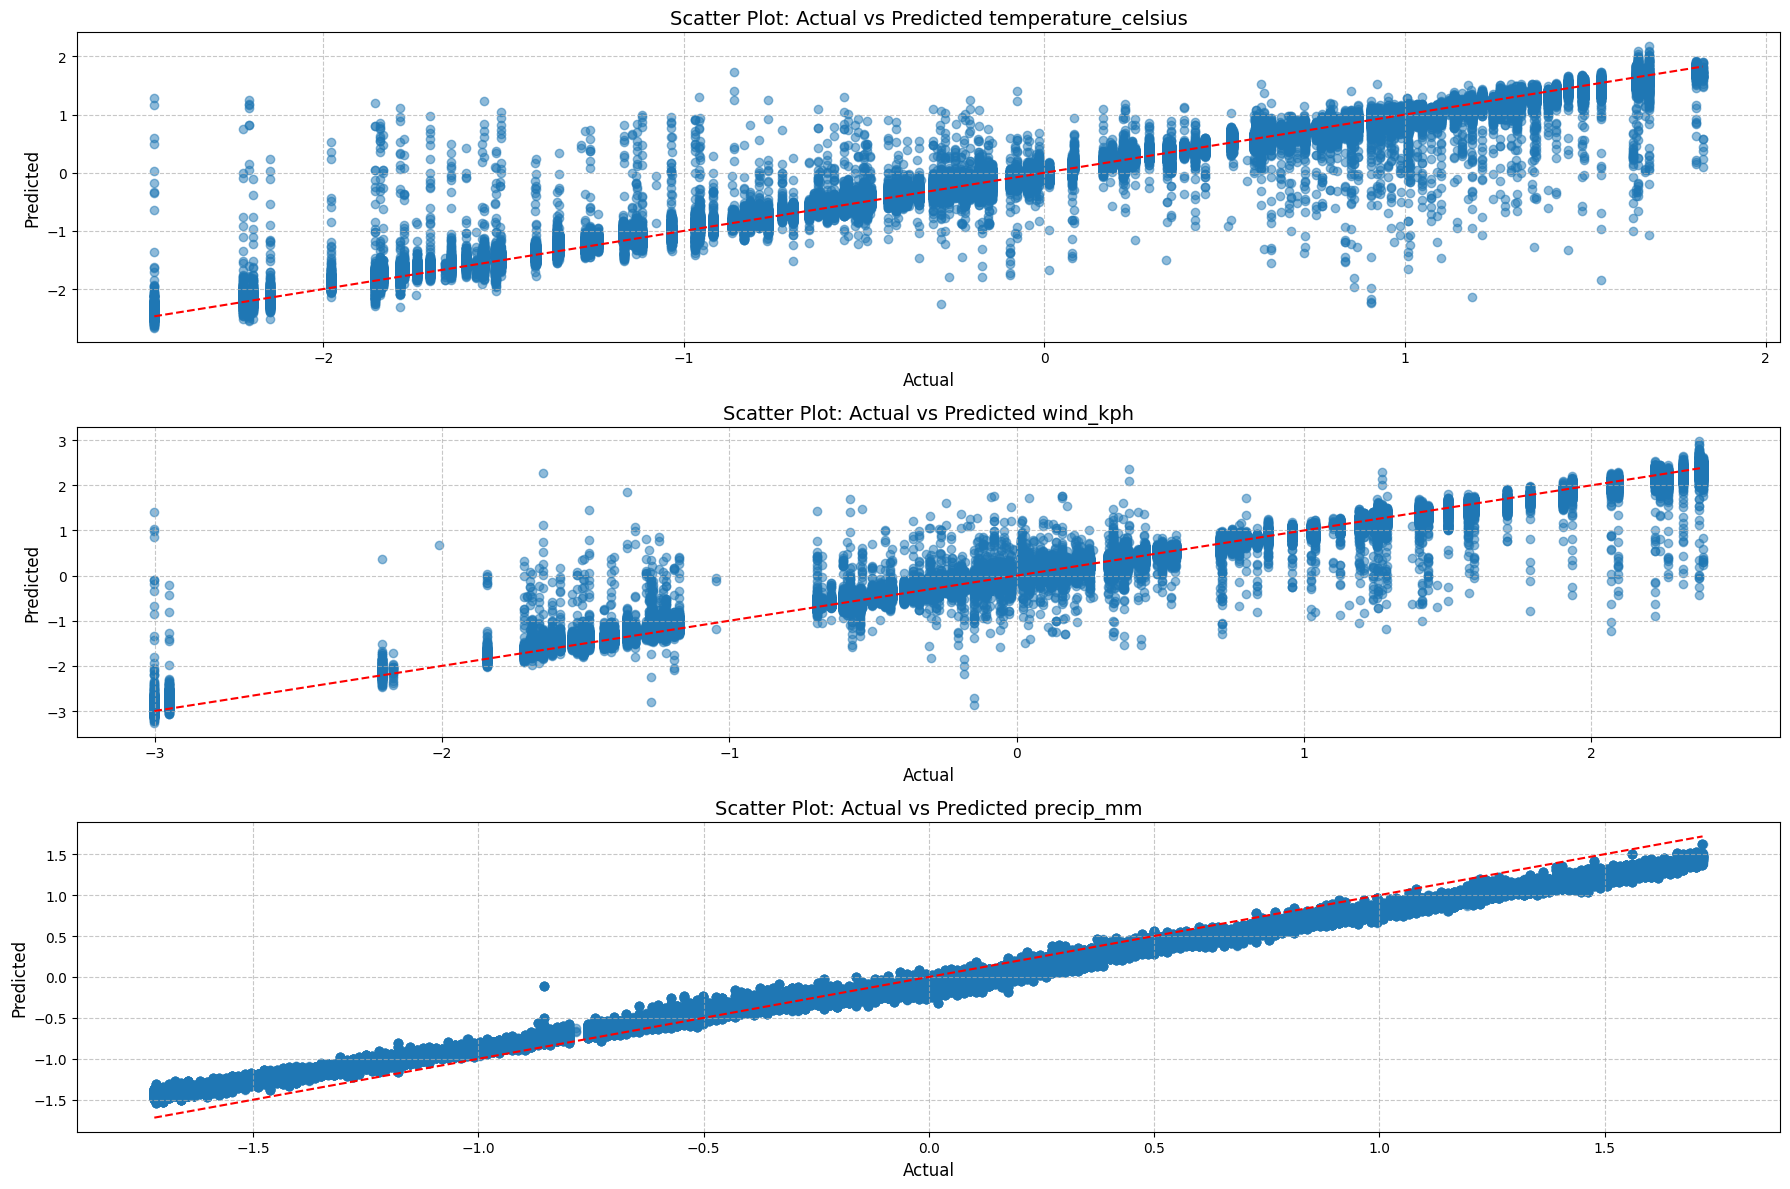

In [70]:
# Scatter Plot
plt.figure(figsize=(18, 12))
for i, target in enumerate(target_names):
    plt.subplot(3, 1, i + 1)
    plt.scatter(y_test_reshaped[:, i], y_pred_reshaped[:, i], alpha=0.5)
    plt.plot([min(y_test_reshaped[:, i]), max(y_test_reshaped[:, i])], 
             [min(y_test_reshaped[:, i]), max(y_test_reshaped[:, i])], 
             color='red', linestyle='--')
    plt.title(f'Scatter Plot: Actual vs Predicted {target}', fontsize=14)
    plt.xlabel('Actual', fontsize=12)
    plt.ylabel('Predicted', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

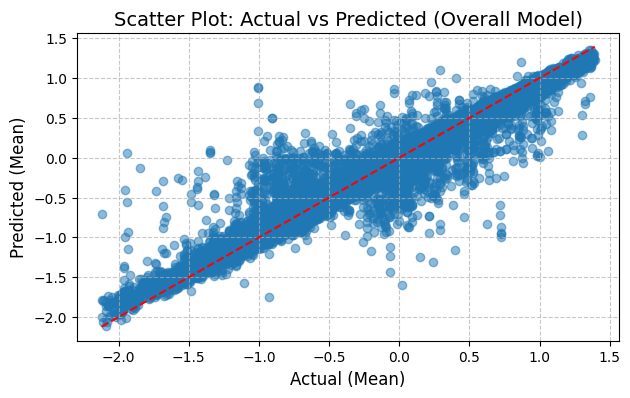

In [81]:
# Scatter Plot for Overall Model
plt.figure(figsize=(7, 4))
plt.scatter(np.mean(y_test_reshaped, axis=1), np.mean(y_pred_reshaped, axis=1), alpha=0.5)
plt.plot([min(np.mean(y_test_reshaped, axis=1)), max(np.mean(y_test_reshaped, axis=1))], 
         [min(np.mean(y_test_reshaped, axis=1)), max(np.mean(y_test_reshaped, axis=1))], 
         color='red', linestyle='--')
plt.title('Scatter Plot: Actual vs Predicted (Overall Model)', fontsize=14)
plt.xlabel('Actual (Mean)', fontsize=12)
plt.ylabel('Predicted (Mean)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

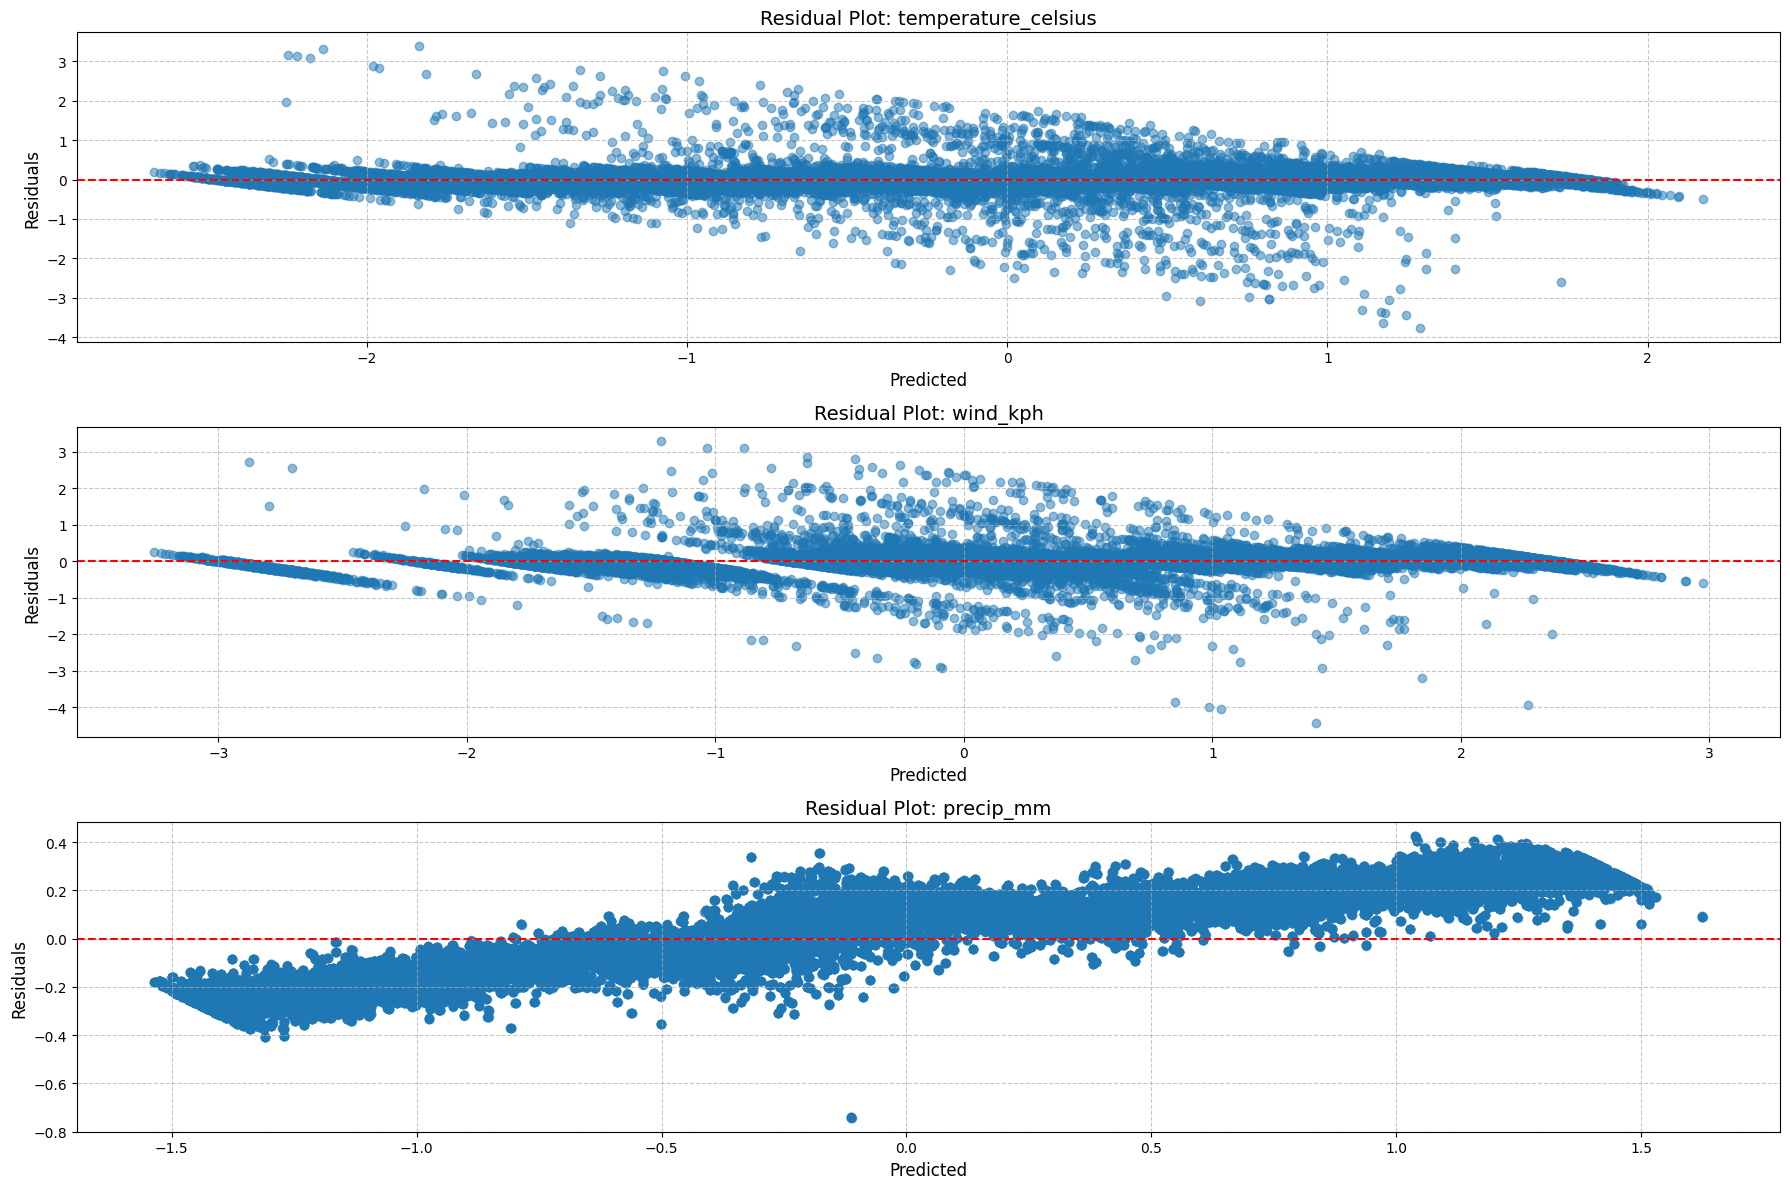

In [68]:
# Residual Plot
plt.figure(figsize=(18, 12))
for i, target in enumerate(target_names):
    residuals = y_test_reshaped[:, i] - y_pred_reshaped[:, i]
    plt.subplot(3, 1, i + 1)
    plt.scatter(y_pred_reshaped[:, i], residuals, alpha=0.5)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.title(f'Residual Plot: {target}', fontsize=14)
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Residuals', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

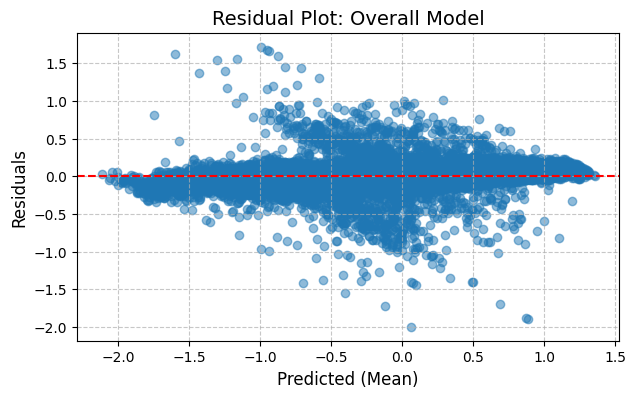

In [82]:
# Residual Plot for Overall Model
residuals = np.mean(y_test_reshaped, axis=1) - np.mean(y_pred_reshaped, axis=1)
plt.figure(figsize=(7, 4))
plt.scatter(np.mean(y_pred_reshaped, axis=1), residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot: Overall Model', fontsize=14)
plt.xlabel('Predicted (Mean)', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

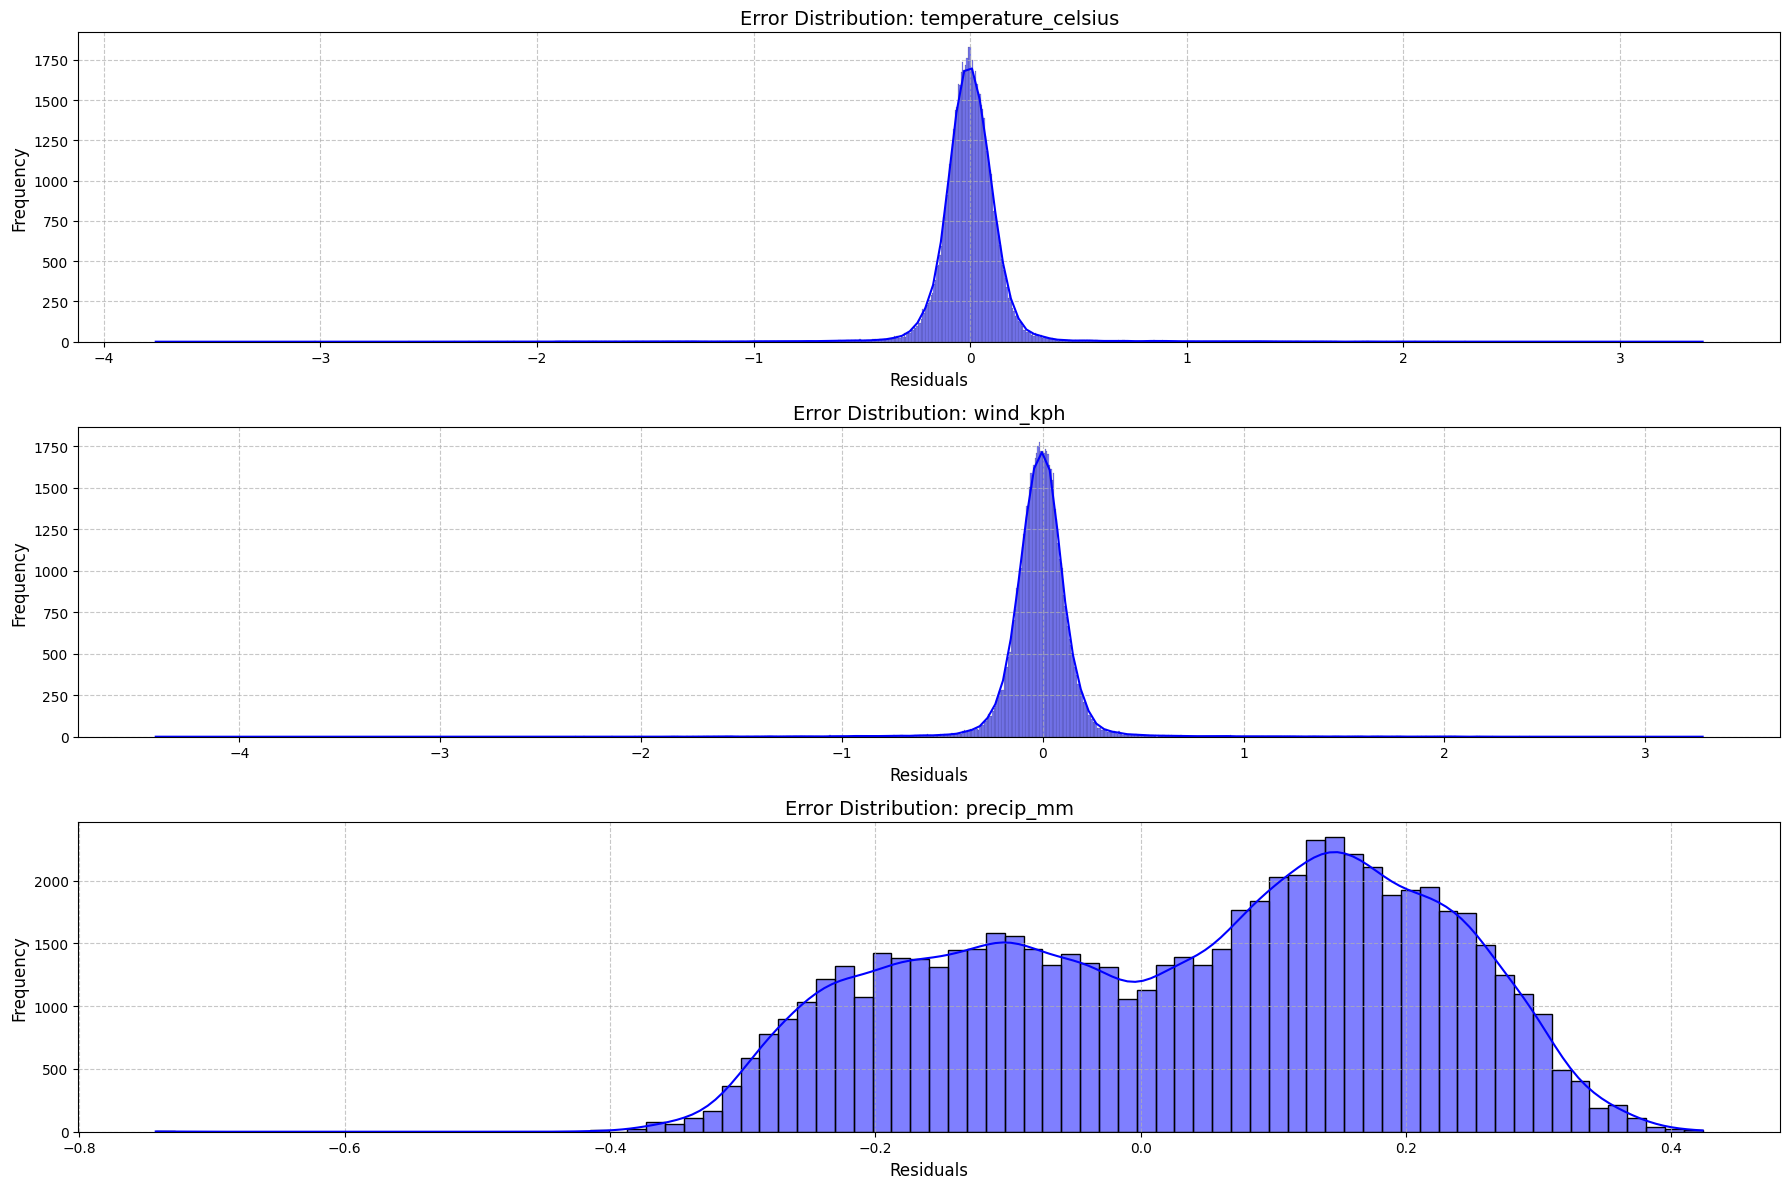

In [69]:
# Error Distribution
plt.figure(figsize=(18, 12))
for i, target in enumerate(target_names):
    residuals = y_test_reshaped[:, i] - y_pred_reshaped[:, i]
    plt.subplot(3, 1, i + 1)
    sns.histplot(residuals, kde=True, color='blue')
    plt.title(f'Error Distribution: {target}', fontsize=14)
    plt.xlabel('Residuals', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

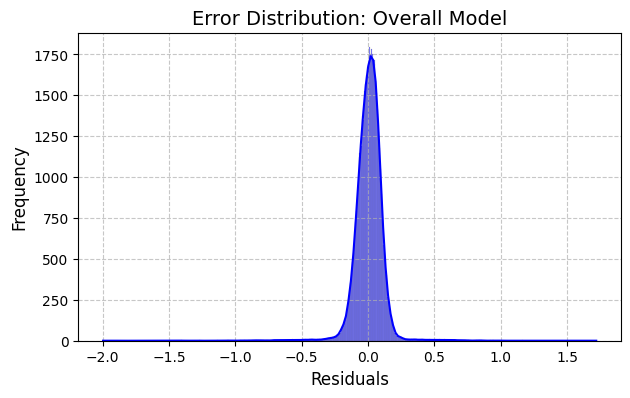

In [83]:
# Error Distribution for Overall Model
plt.figure(figsize=(7, 4))
sns.histplot(residuals, kde=True, color='blue')
plt.title('Error Distribution: Overall Model', fontsize=14)
plt.xlabel('Residuals', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

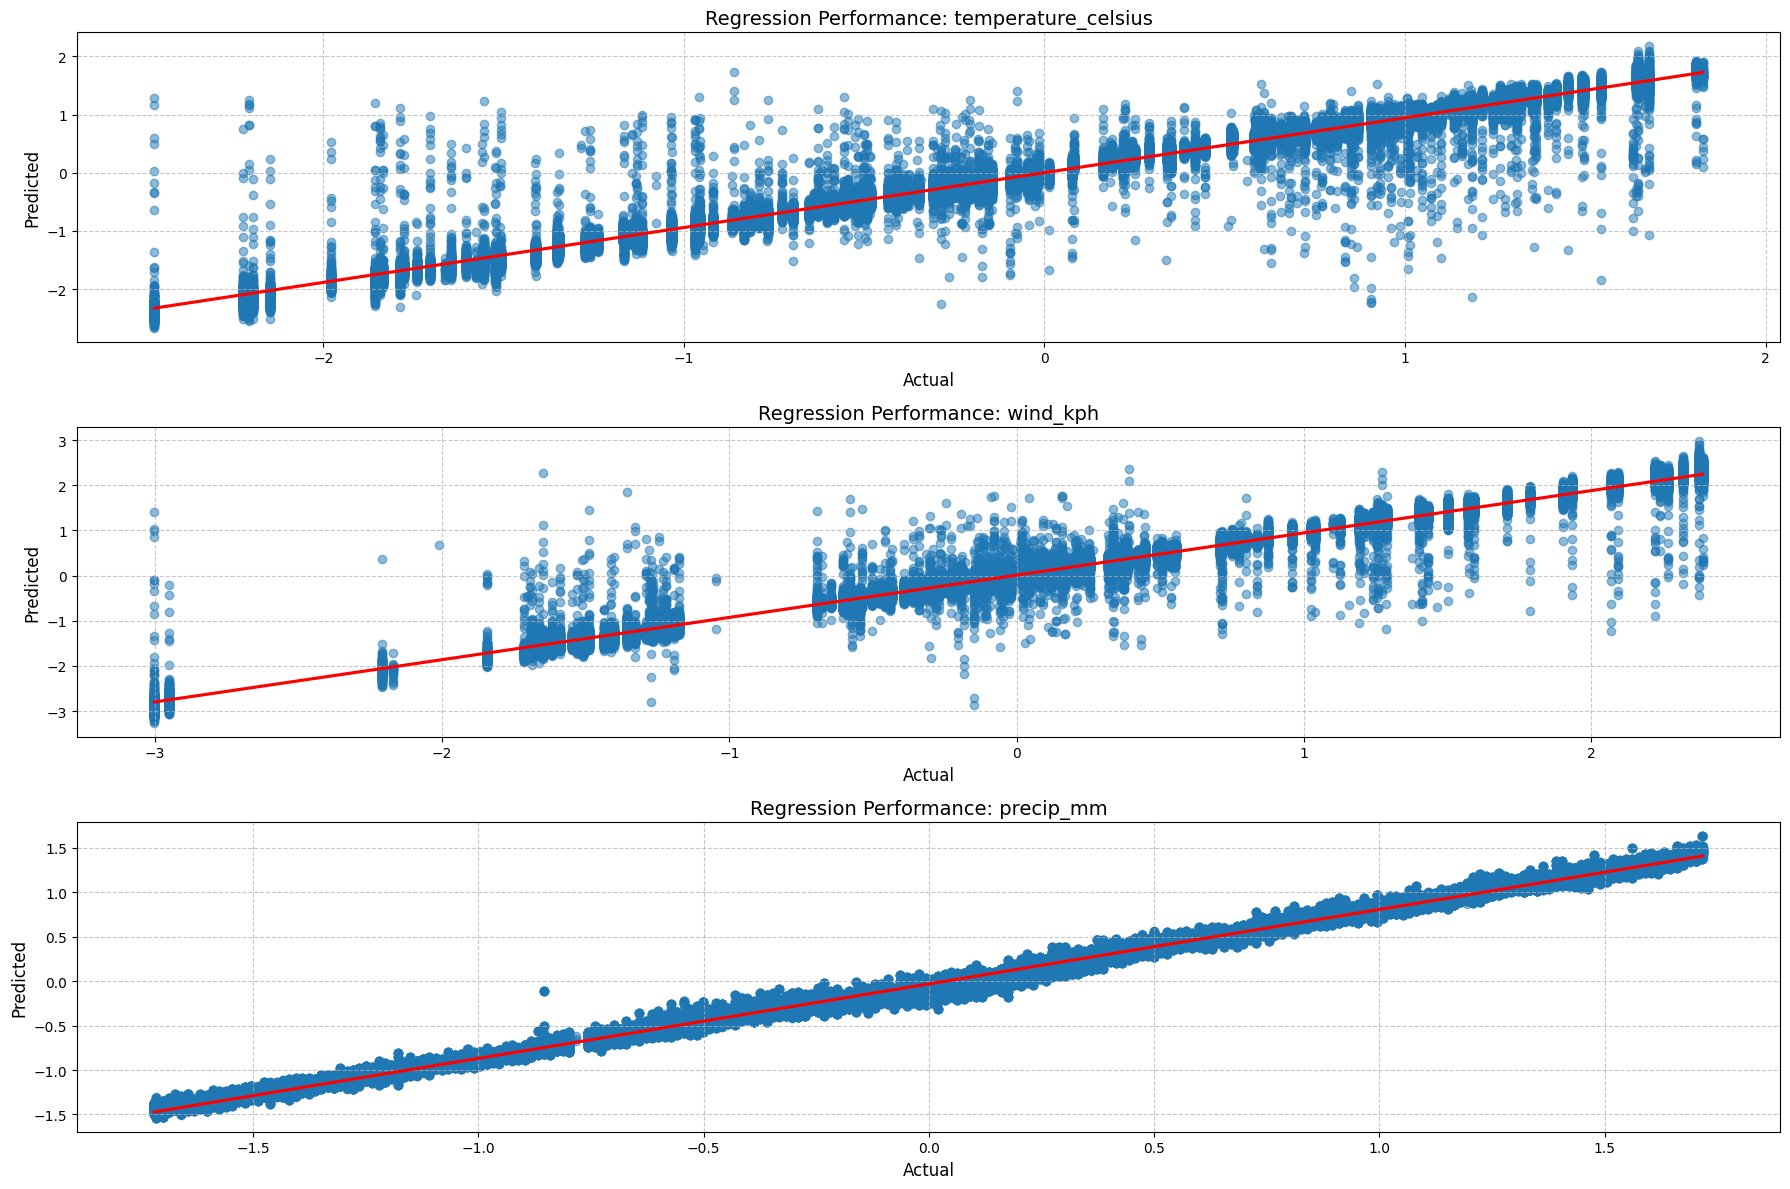

In [67]:
# Regression Performance Plot
plt.figure(figsize=(18, 12))
for i, target in enumerate(target_names):
    plt.subplot(3, 1, i + 1)
    sns.regplot(x=y_test_reshaped[:, i], y=y_pred_reshaped[:, i], scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
    plt.title(f'Regression Performance: {target}', fontsize=14)
    plt.xlabel('Actual', fontsize=12)
    plt.ylabel('Predicted', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

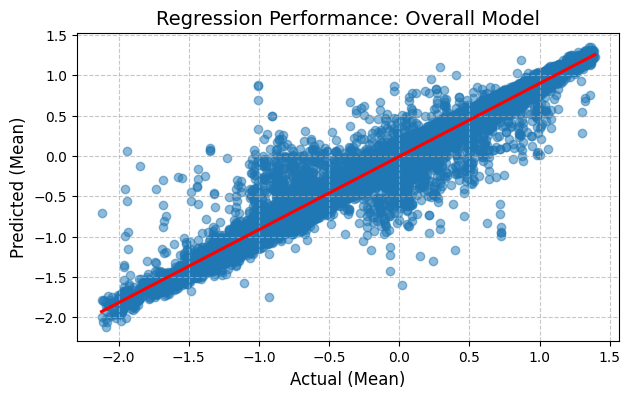

In [84]:
# Regression Performance Plot for Overall Model
plt.figure(figsize=(7, 4))
sns.regplot(x=np.mean(y_test_reshaped, axis=1), y=np.mean(y_pred_reshaped, axis=1), scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title('Regression Performance: Overall Model', fontsize=14)
plt.xlabel('Actual (Mean)', fontsize=12)
plt.ylabel('Predicted (Mean)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

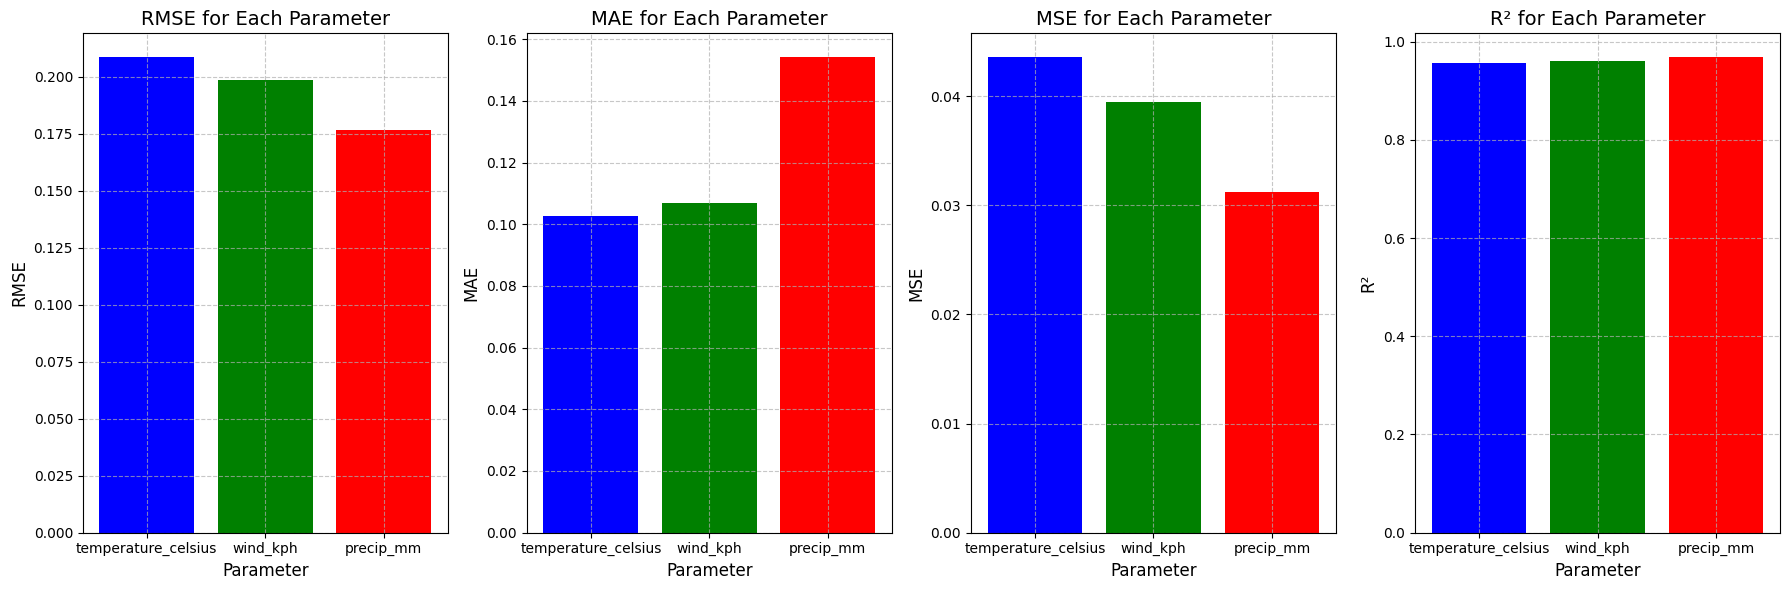

In [52]:
# Bar Plot: RMSE, MAE, MSE, R²
metrics = ['RMSE', 'MAE', 'MSE', 'R²']
values = {
    'temperature_celsius': [0.2087, 0.1028, 0.0436, 0.9565],
    'wind_kph': [0.1988, 0.1068, 0.0395, 0.9605],
    'precip_mm': [0.1767, 0.1542, 0.0312, 0.9689]
}

plt.figure(figsize=(18, 6))
for i, metric in enumerate(metrics):
    plt.subplot(1, 4, i + 1)
    plt.bar(target_names, [values[target][i] for target in target_names], color=['blue', 'green', 'red'])
    plt.title(f'{metric} for Each Parameter', fontsize=14)
    plt.xlabel('Parameter', fontsize=12)
    plt.ylabel(metric, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

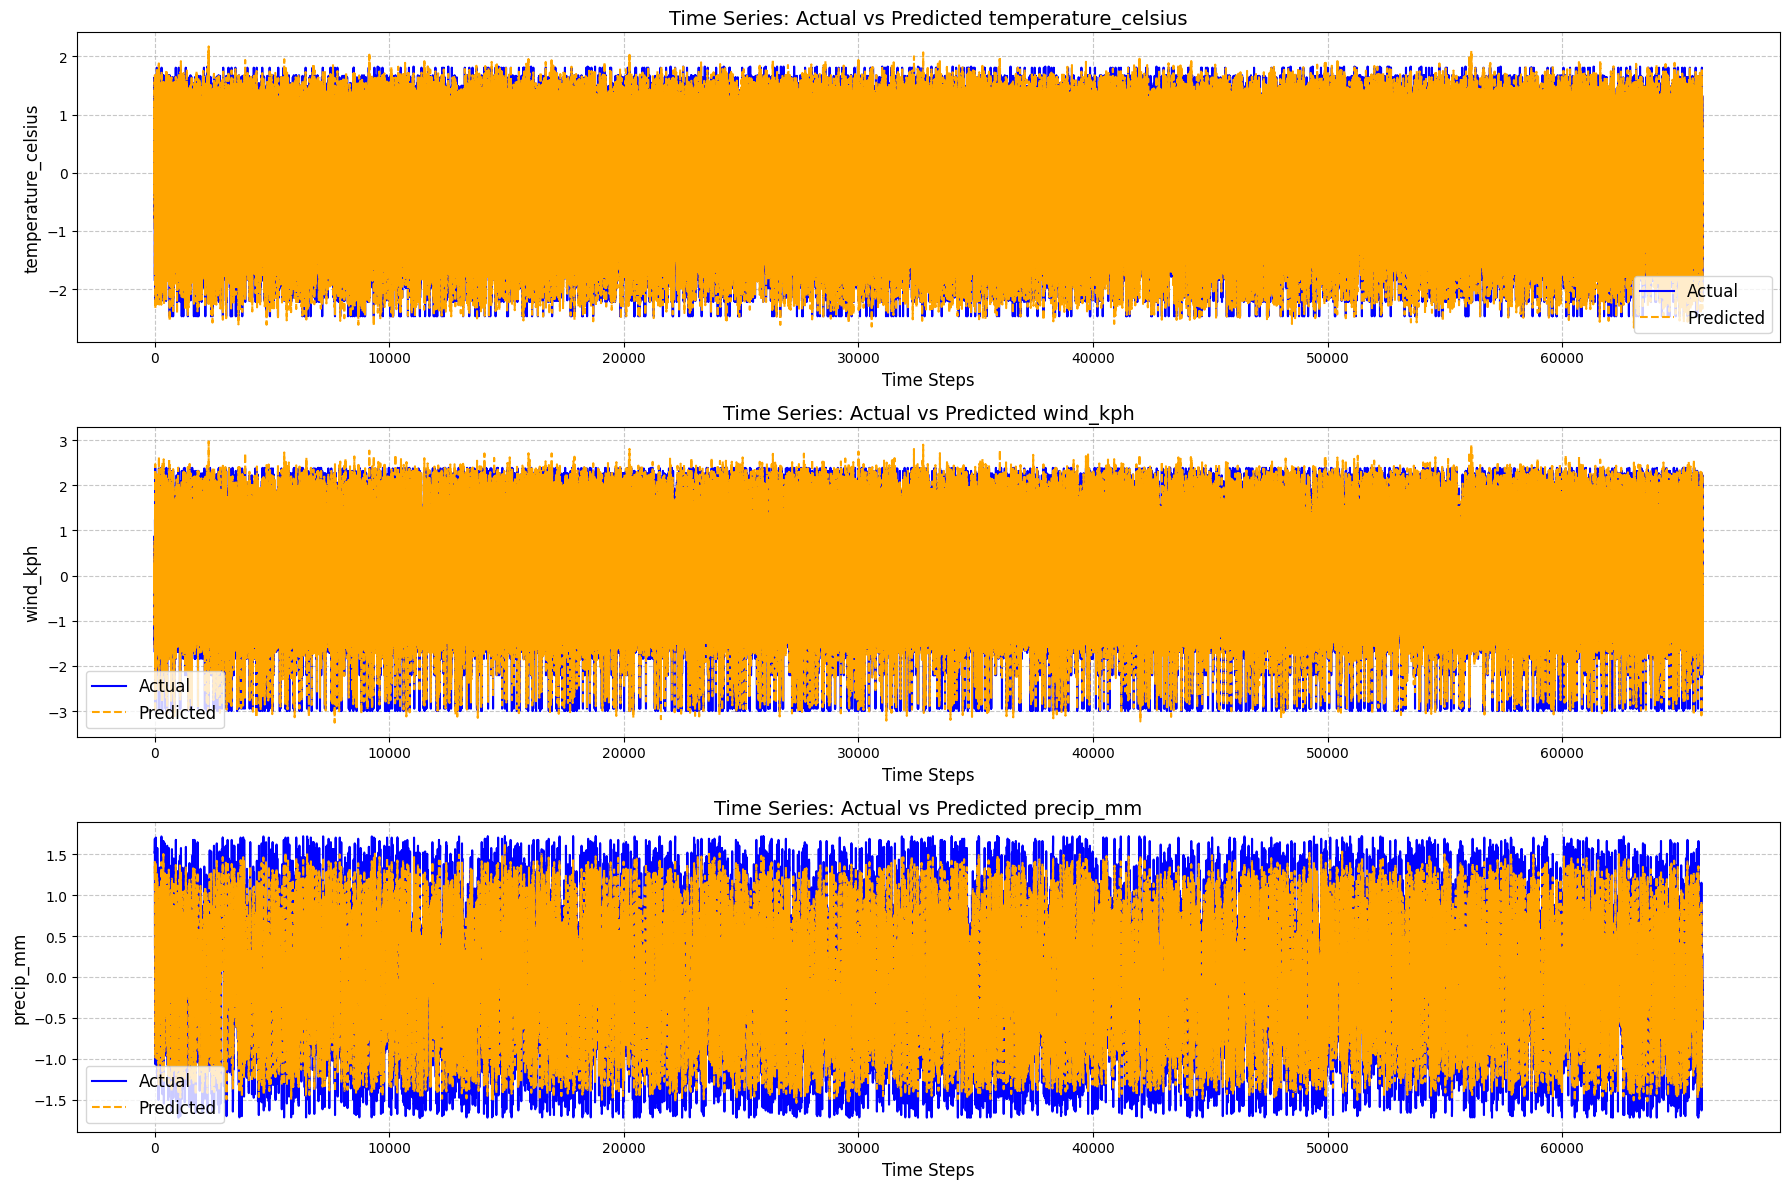

In [66]:
# Time Series Plot
plt.figure(figsize=(18, 12))
for i, target in enumerate(target_names):
    plt.subplot(3, 1, i + 1)
    plt.plot(y_test_reshaped[:, i], label='Actual', color='blue', linewidth=1.5)
    plt.plot(y_pred_reshaped[:, i], label='Predicted', color='orange', linestyle='--', linewidth=1.5)
    plt.title(f'Time Series: Actual vs Predicted {target}', fontsize=14)
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel(target, fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

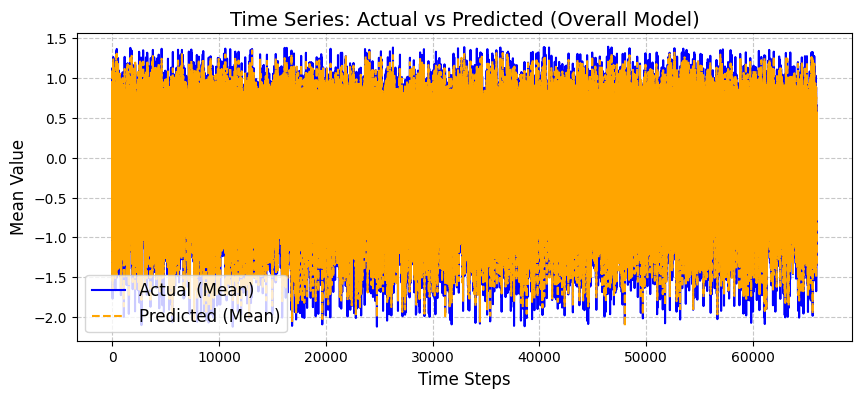

In [92]:
# Time Series Plot for Overall Model
plt.figure(figsize=(10, 4))
plt.plot(np.mean(y_test_reshaped, axis=1), label='Actual (Mean)', color='blue', linewidth=1.5)
plt.plot(np.mean(y_pred_reshaped, axis=1), label='Predicted (Mean)', color='orange', linestyle='--', linewidth=1.5)
plt.title('Time Series: Actual vs Predicted (Overall Model)', fontsize=14)
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Mean Value', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

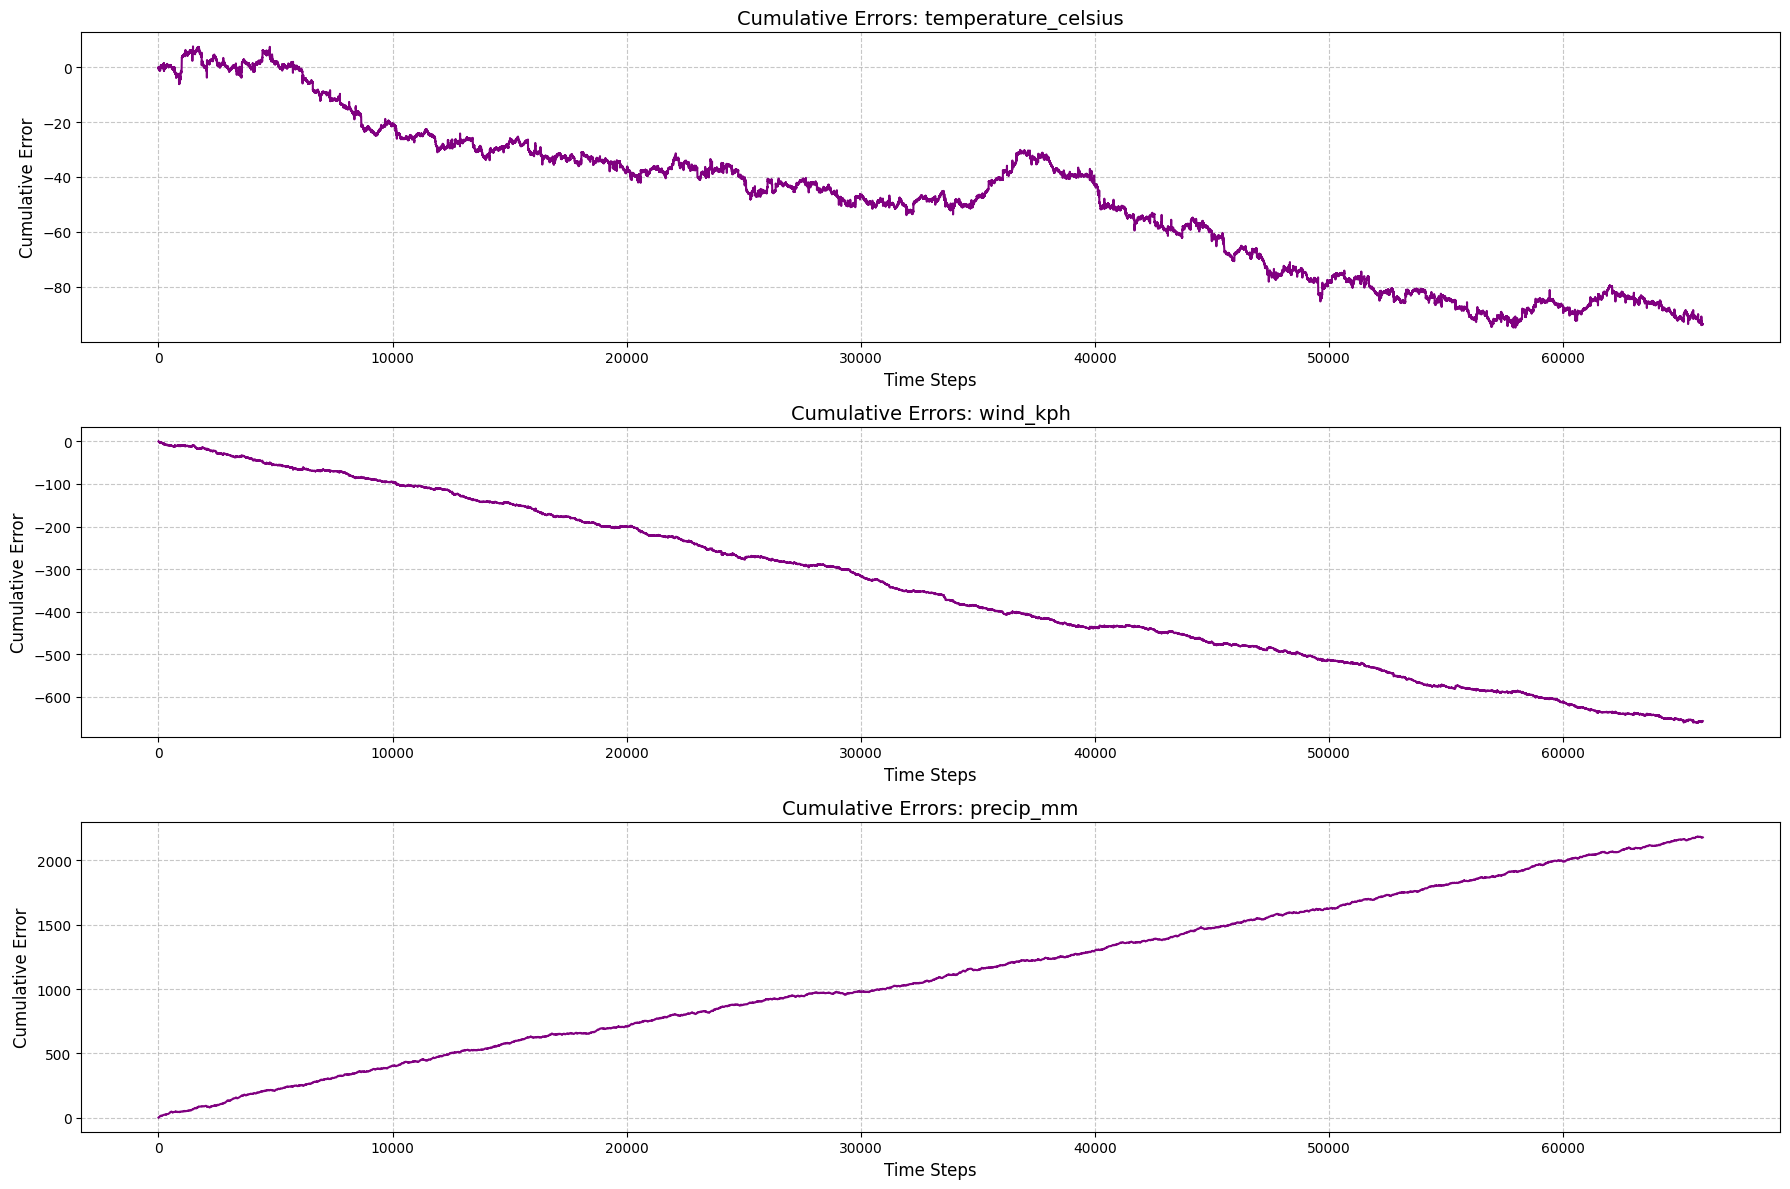

In [65]:
# Cumulative Errors
plt.figure(figsize=(18, 12))
for i, target in enumerate(target_names):
    residuals = y_test_reshaped[:, i] - y_pred_reshaped[:, i]
    cumulative_errors = np.cumsum(residuals)
    plt.subplot(3, 1, i + 1)
    plt.plot(cumulative_errors, color='purple', linewidth=1.5)
    plt.title(f'Cumulative Errors: {target}', fontsize=14)
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel('Cumulative Error', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

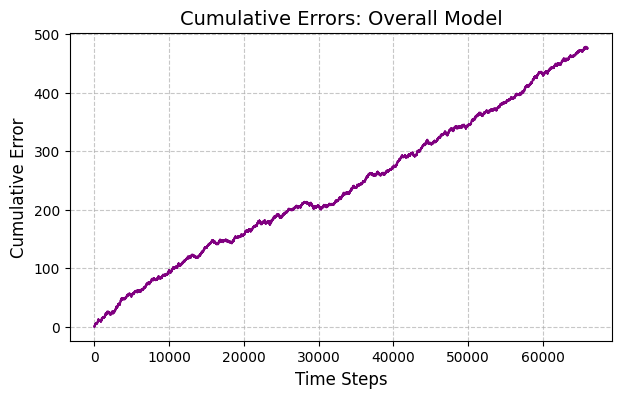

In [96]:
# Cumulative Errors for Overall Model
cumulative_errors = np.cumsum(residuals)
plt.figure(figsize=(7, 4))
plt.plot(cumulative_errors, color='purple', linewidth=1.5)
plt.title('Cumulative Errors: Overall Model', fontsize=14)
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Cumulative Error', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

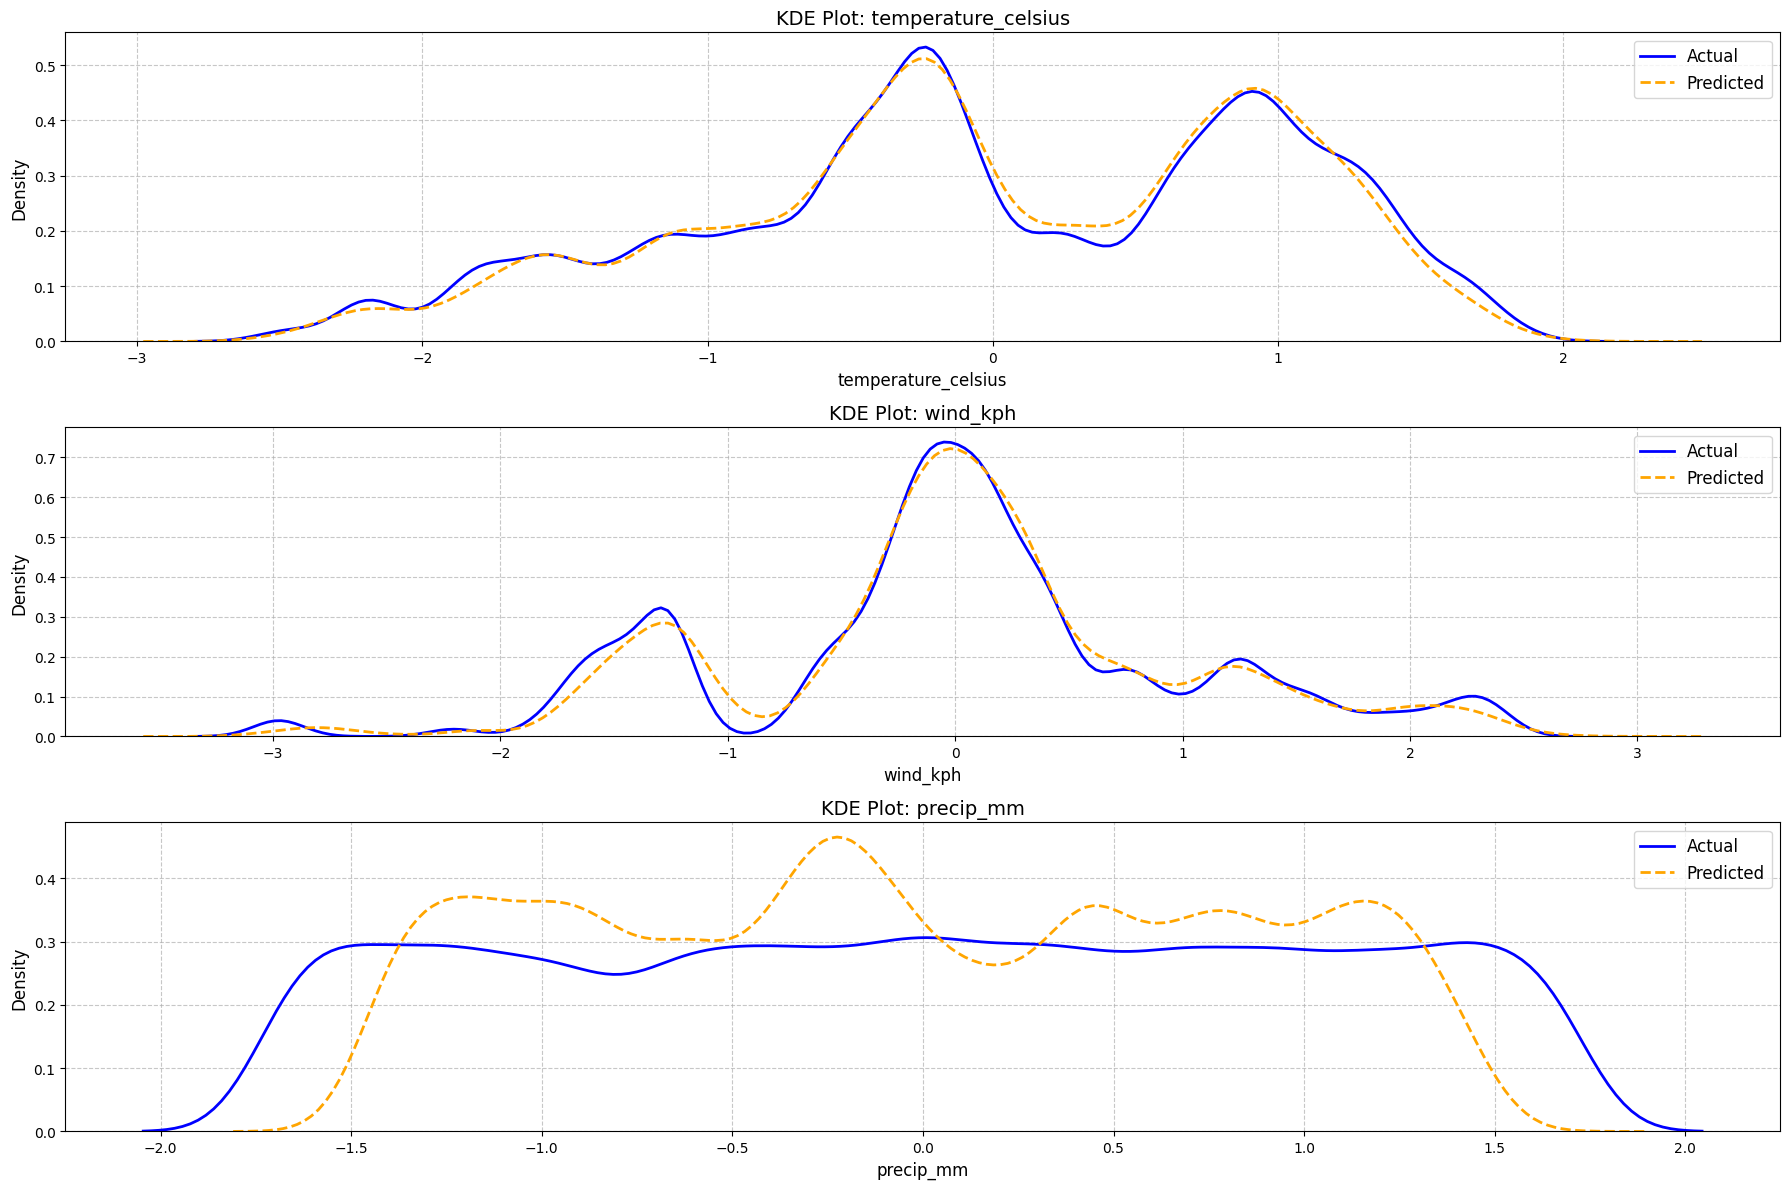

In [74]:
# KDE Plot
plt.figure(figsize=(18, 12))
for i, target in enumerate(target_names):
    plt.subplot(3, 1, i + 1)
    sns.kdeplot(y_test_reshaped[:, i], label='Actual', color='blue', linewidth=2)
    sns.kdeplot(y_pred_reshaped[:, i], label='Predicted', color='orange', linestyle='--', linewidth=2)
    plt.title(f'KDE Plot: {target}', fontsize=14)
    plt.xlabel(target, fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

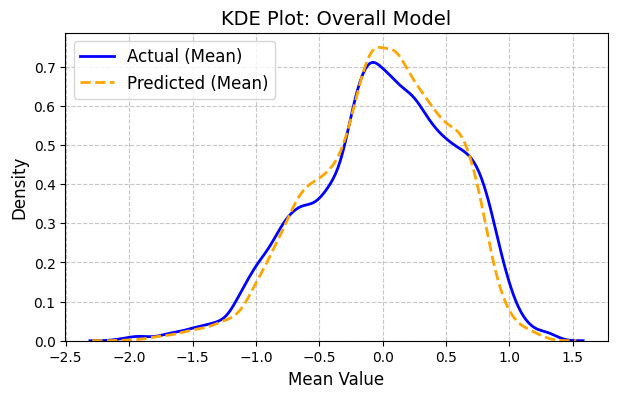

In [105]:
# KDE Plot for Overall Model
plt.figure(figsize=(7, 4))
sns.kdeplot(np.mean(y_test_reshaped, axis=1), label='Actual (Mean)', color='blue', linewidth=2)
sns.kdeplot(np.mean(y_pred_reshaped, axis=1), label='Predicted (Mean)', color='orange', linestyle='--', linewidth=2)
plt.title('KDE Plot: Overall Model', fontsize=14)
plt.xlabel('Mean Value', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

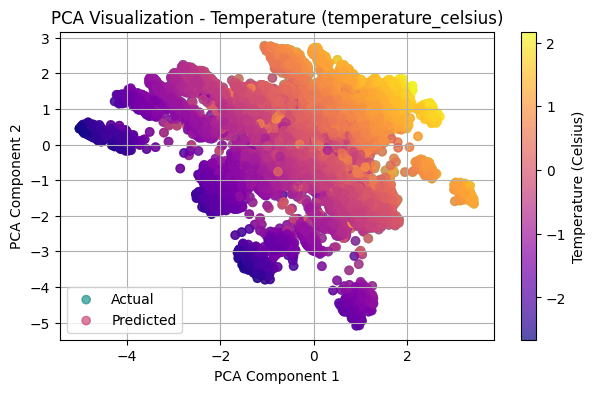

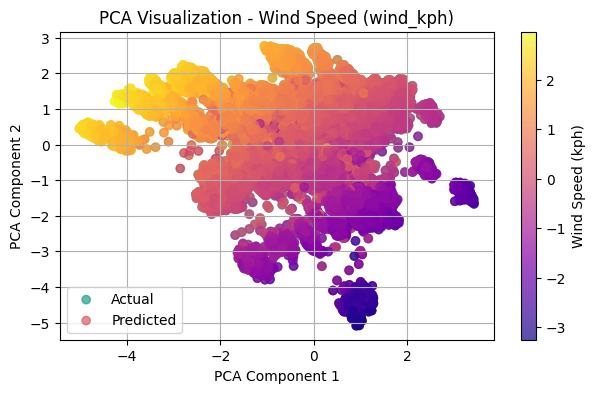

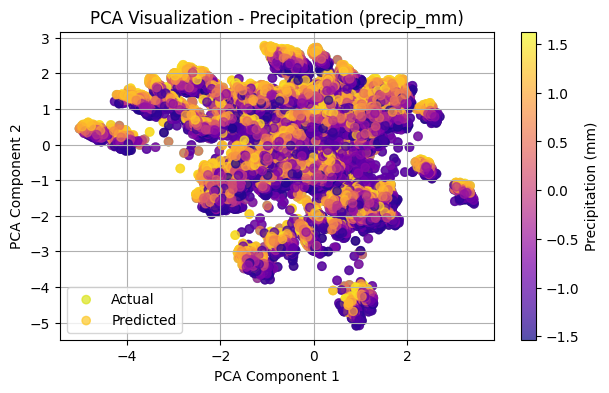

In [79]:
from sklearn.decomposition import PCA

# Perform PCA on the combined actual and predicted values
pca = PCA(n_components=2)
pca_result = pca.fit_transform(np.hstack((y_test_reshaped, y_pred_reshaped)))

# PCA Visualization for Temperature
plt.figure(figsize=(7, 4))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=y_test_reshaped[:, 0], cmap='viridis', label="Actual", alpha=0.7)
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=y_pred_reshaped[:, 0], cmap='plasma', label="Predicted", alpha=0.7)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Visualization - Temperature (temperature_celsius)")
plt.colorbar(label="Temperature (Celsius)")
plt.legend()
plt.grid()
plt.show()

# PCA Visualization for Wind Speed
plt.figure(figsize=(7, 4))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=y_test_reshaped[:, 1], cmap='viridis', label="Actual", alpha=0.7)
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=y_pred_reshaped[:, 1], cmap='plasma', label="Predicted", alpha=0.7)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Visualization - Wind Speed (wind_kph)")
plt.colorbar(label="Wind Speed (kph)")
plt.legend()
plt.grid()
plt.show()

# PCA Visualization for Precipitation
plt.figure(figsize=(7, 4))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=y_test_reshaped[:, 2], cmap='viridis', label="Actual", alpha=0.7)
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=y_pred_reshaped[:, 2], cmap='plasma', label="Predicted", alpha=0.7)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Visualization - Precipitation (precip_mm)")
plt.colorbar(label="Precipitation (mm)")
plt.legend()
plt.grid()
plt.show()

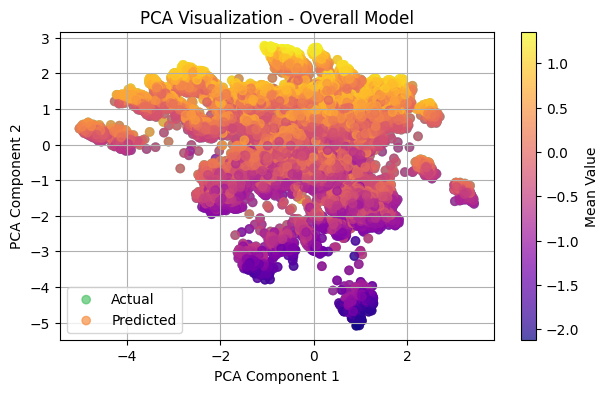

In [80]:
# PCA Visualization for Overall Model
plt.figure(figsize=(7, 4))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=np.mean(y_test_reshaped, axis=1), cmap='viridis', label="Actual", alpha=0.7)
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=np.mean(y_pred_reshaped, axis=1), cmap='plasma', label="Predicted", alpha=0.7)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Visualization - Overall Model")
plt.colorbar(label="Mean Value")
plt.legend()
plt.grid()
plt.show()

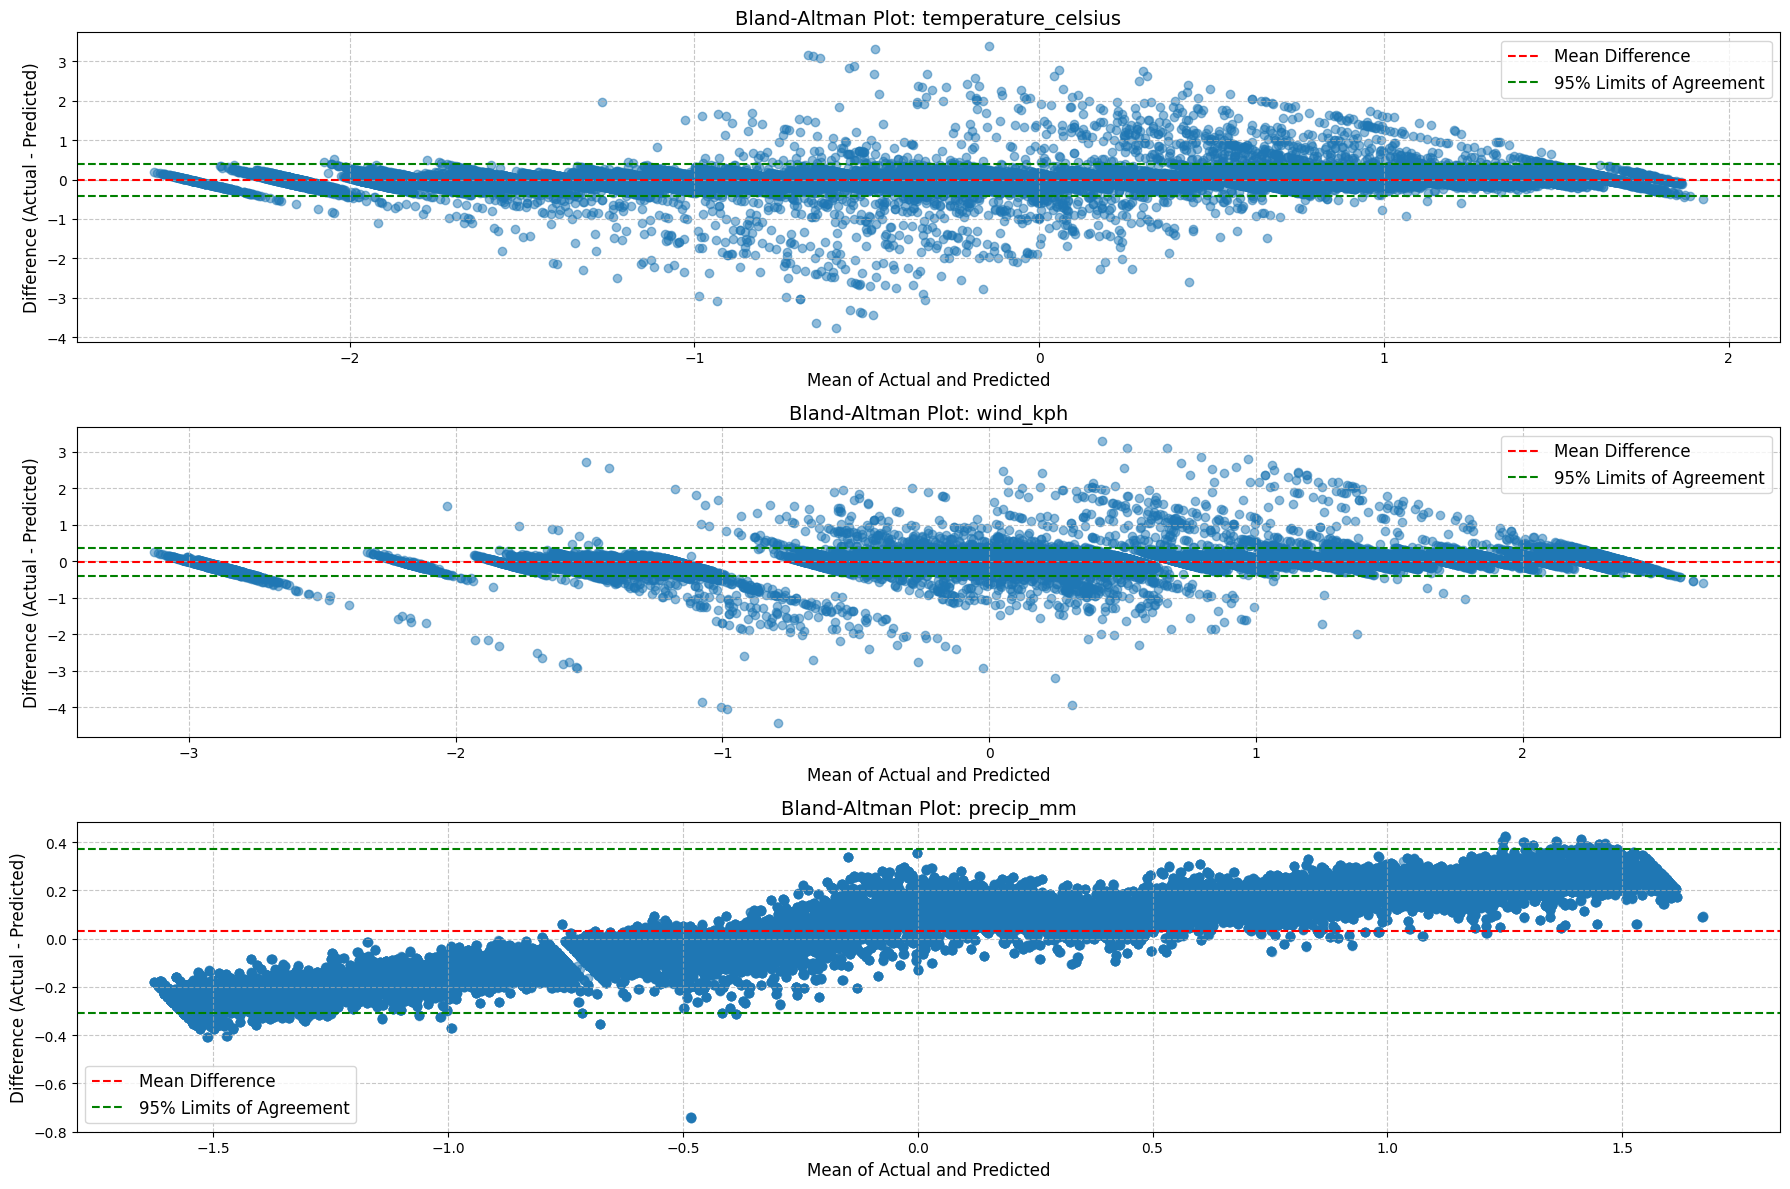

In [75]:
# Bland-Altman Plot
plt.figure(figsize=(18, 12))
for i, target in enumerate(target_names):
    differences = y_test_reshaped[:, i] - y_pred_reshaped[:, i]
    means = (y_test_reshaped[:, i] + y_pred_reshaped[:, i]) / 2
    plt.subplot(3, 1, i + 1)
    plt.scatter(means, differences, alpha=0.5)
    plt.axhline(y=np.mean(differences), color='red', linestyle='--', label='Mean Difference')
    plt.axhline(y=np.mean(differences) + 1.96 * np.std(differences), color='green', linestyle='--', label='95% Limits of Agreement')
    plt.axhline(y=np.mean(differences) - 1.96 * np.std(differences), color='green', linestyle='--')
    plt.title(f'Bland-Altman Plot: {target}', fontsize=14)
    plt.xlabel('Mean of Actual and Predicted', fontsize=12)
    plt.ylabel('Difference (Actual - Predicted)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

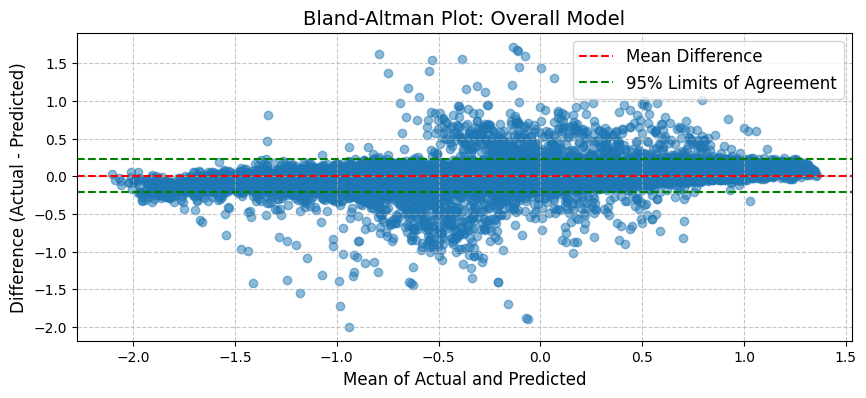

In [130]:
# Bland-Altman Plot for Overall Model
differences = np.mean(y_test_reshaped, axis=1) - np.mean(y_pred_reshaped, axis=1)
means = (np.mean(y_test_reshaped, axis=1) + np.mean(y_pred_reshaped, axis=1)) / 2

plt.figure(figsize=(10, 4))
plt.scatter(means, differences, alpha=0.5)
plt.axhline(y=np.mean(differences), color='red', linestyle='--', label='Mean Difference')
plt.axhline(y=np.mean(differences) + 1.96 * np.std(differences), color='green', linestyle='--', label='95% Limits of Agreement')
plt.axhline(y=np.mean(differences) - 1.96 * np.std(differences), color='green', linestyle='--')
plt.title('Bland-Altman Plot: Overall Model', fontsize=14)
plt.xlabel('Mean of Actual and Predicted', fontsize=12)
plt.ylabel('Difference (Actual - Predicted)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

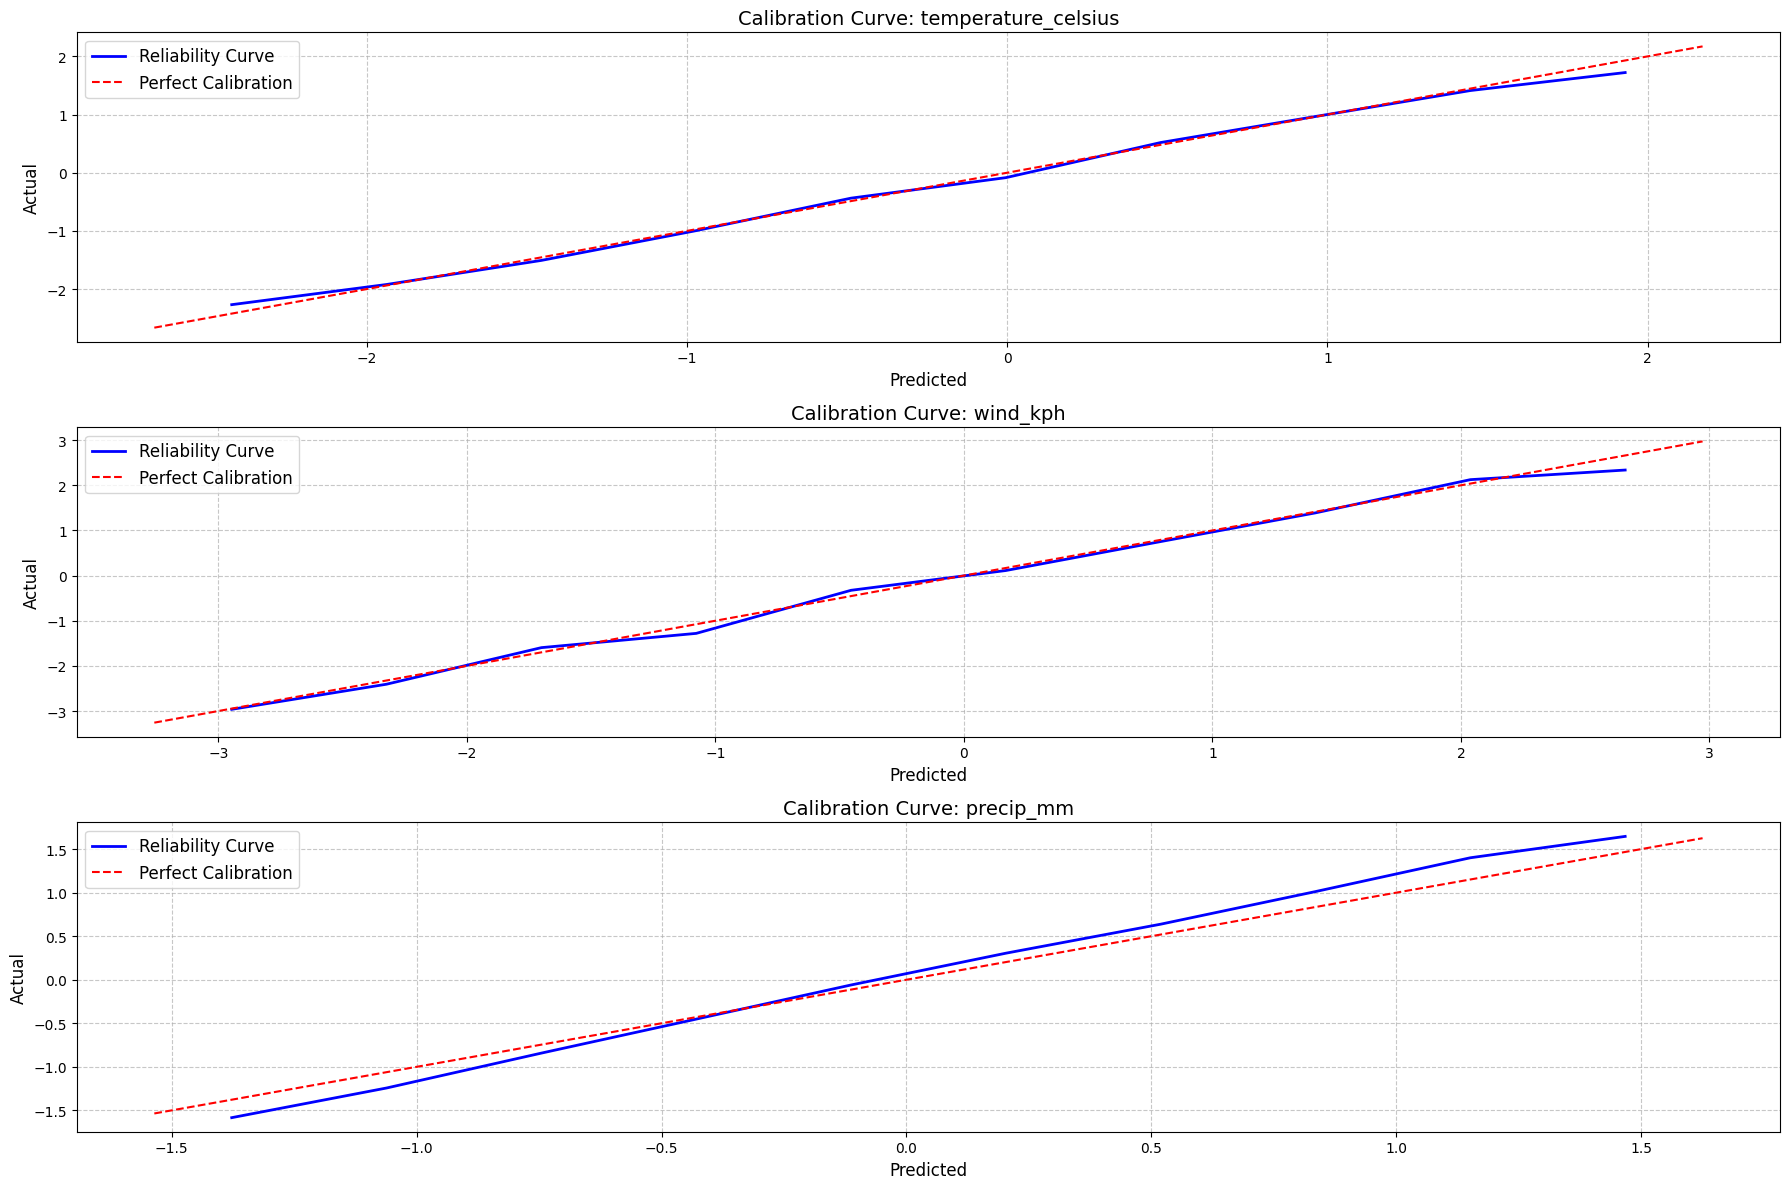

In [110]:
from scipy import stats  # Import the stats module

# Reliability Plot (Regression Calibration Curve)
plt.figure(figsize=(18, 12))
for i, target in enumerate(target_names):
    # Bin the predictions and compute mean actual values
    bin_means, bin_edges, _ = stats.binned_statistic(y_pred_reshaped[:, i], y_test_reshaped[:, i], statistic='mean', bins=10)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    plt.subplot(3, 1, i + 1)
    plt.plot(bin_centers, bin_means, label='Reliability Curve', color='blue', linewidth=2)
    plt.plot([min(y_pred_reshaped[:, i]), max(y_pred_reshaped[:, i])], 
             [min(y_pred_reshaped[:, i]), max(y_pred_reshaped[:, i])], 
             color='red', linestyle='--', label='Perfect Calibration')
    plt.title(f'Calibration Curve: {target}', fontsize=14)
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Actual', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [113]:
# Compute mean actual and predicted values
mean_actual = np.mean(y_test_reshaped, axis=1)
mean_predicted = np.mean(y_pred_reshaped, axis=1)

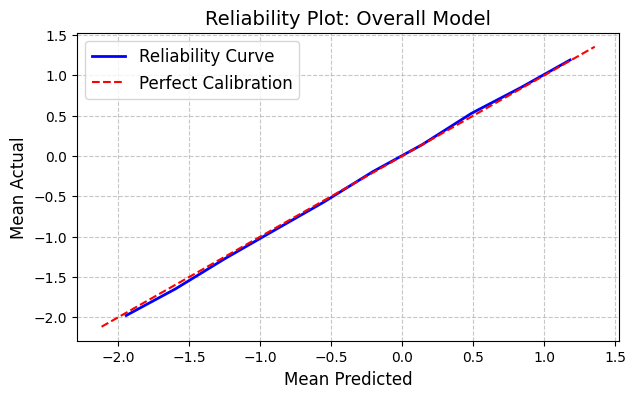

In [114]:
from scipy import stats  # Import the stats module

# Reliability Plot for Overall Model
plt.figure(figsize=(7, 4))

# Bin the predictions and compute mean actual values
bin_means, bin_edges, _ = stats.binned_statistic(mean_predicted, mean_actual, statistic='mean', bins=10)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Plot the reliability curve
plt.plot(bin_centers, bin_means, label='Reliability Curve', color='blue', linewidth=2)

# Plot the perfect calibration line
plt.plot([min(mean_predicted), max(mean_predicted)], 
         [min(mean_predicted), max(mean_predicted)], 
         color='red', linestyle='--', label='Perfect Calibration')

# Add labels, title, and legend
plt.title('Reliability Plot: Overall Model', fontsize=14)
plt.xlabel('Mean Predicted', fontsize=12)
plt.ylabel('Mean Actual', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [98]:
# List all variables currently in memory
import sys

variables = {name: type(value) for name, value in globals().items()}
for var_name, var_type in variables.items():
    print(f"{var_name}: {var_type}")


__name__: <class 'str'>
__doc__: <class 'str'>
__package__: <class 'NoneType'>
__loader__: <class 'NoneType'>
__spec__: <class 'NoneType'>
__builtin__: <class 'module'>
__builtins__: <class 'module'>
_ih: <class 'list'>
_oh: <class 'dict'>
_dh: <class 'list'>
In: <class 'list'>
Out: <class 'dict'>
get_ipython: <class 'method'>
exit: <class 'IPython.core.autocall.ZMQExitAutocall'>
quit: <class 'IPython.core.autocall.ZMQExitAutocall'>
open: <class 'function'>
_: <class 'pandas.core.frame.DataFrame'>
__: <class 'pandas.core.frame.DataFrame'>
___: <class 'pandas.core.frame.DataFrame'>
__session__: <class 'str'>
_i: <class 'str'>
_ii: <class 'str'>
_iii: <class 'str'>
_i1: <class 'str'>
np: <class 'module'>
pd: <class 'module'>
plt: <class 'module'>
sns: <class 'module'>
train_test_split: <class 'function'>
StandardScaler: <class 'type'>
mean_squared_error: <class 'function'>
mean_absolute_error: <class 'function'>
r2_score: <class 'function'>
Sequential: <class 'type'>
Input: <class 'funct

In [99]:
print("Actual values (y_test_reshaped):", y_test_reshaped.shape)
print(y_test_reshaped[:5])  # Print first 5 actual values

print("Predicted values (y_pred_reshaped):", y_pred_reshaped.shape)
print(y_pred_reshaped[:5])  # Print first 5 predicted values


Actual values (y_test_reshaped): (65975, 3)
[[-0.28564079  0.03405877  1.51888225]
 [ 0.86827577 -0.39360831  1.51858778]
 [-0.49878246  0.8761859   1.51888225]
 [-0.14520608  0.15695036  1.51858778]
 [-0.54365653 -1.17623087  1.51888225]]
Predicted values (y_pred_reshaped): (65975, 3)
[[-0.19698235  0.2678335   1.2616487 ]
 [ 0.80983806 -0.34437498  1.2617072 ]
 [-0.371685    0.7598156   1.2617662 ]
 [-0.13708234  0.09561925  1.2618513 ]
 [-0.41963422 -1.0834177   1.2625221 ]]


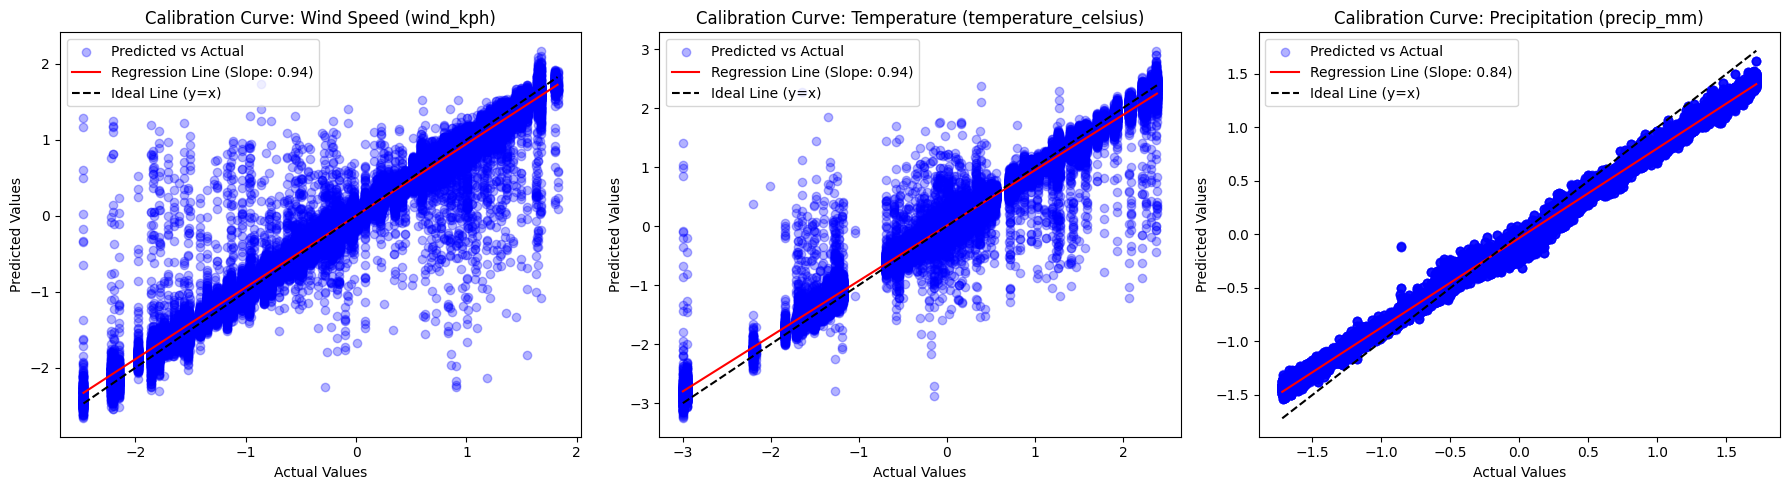

In [111]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Define parameter names
param_names = ["Wind Speed (wind_kph)", "Temperature (temperature_celsius)", "Precipitation (precip_mm)"]

# Create a figure for subplots (3 side-by-side plots)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i in range(3):  # Iterate through the three target variables
    actual = y_test_reshaped[:, i]
    predicted = y_pred_reshaped[:, i]

    # Fit a regression line
    reg = LinearRegression().fit(actual.reshape(-1, 1), predicted)
    line_x = np.linspace(min(actual), max(actual), 100)
    line_y = reg.predict(line_x.reshape(-1, 1))

    # Scatter plot with regression line
    axes[i].scatter(actual, predicted, alpha=0.3, label="Predicted vs Actual", color="blue")
    axes[i].plot(line_x, line_y, color="red", label=f"Regression Line (Slope: {reg.coef_[0]:.2f})")
    axes[i].plot(line_x, line_x, color="black", linestyle="--", label="Ideal Line (y=x)")

    axes[i].set_xlabel("Actual Values")
    axes[i].set_ylabel("Predicted Values")
    axes[i].set_title(f"Calibration Curve: {param_names[i]}")
    axes[i].legend()

plt.tight_layout()
plt.show()


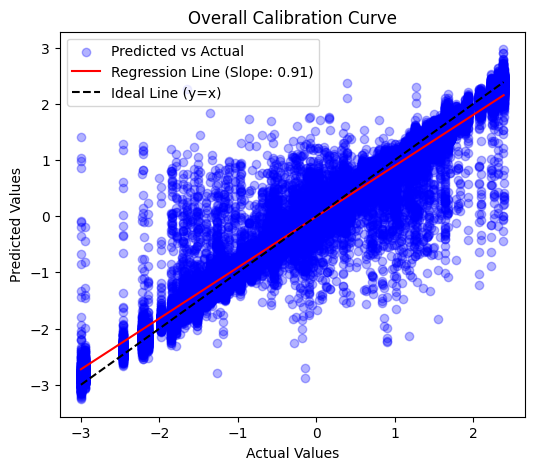

In [112]:
# Flatten actual and predicted values for all three parameters
actual_flat = y_test_reshaped.flatten()
predicted_flat = y_pred_reshaped.flatten()

# Fit regression
reg = LinearRegression().fit(actual_flat.reshape(-1, 1), predicted_flat)
line_x = np.linspace(min(actual_flat), max(actual_flat), 100)
line_y = reg.predict(line_x.reshape(-1, 1))

# Plot overall calibration curve
plt.figure(figsize=(6, 5))
plt.scatter(actual_flat, predicted_flat, alpha=0.3, label="Predicted vs Actual", color="blue")
plt.plot(line_x, line_y, color="red", label=f"Regression Line (Slope: {reg.coef_[0]:.2f})")
plt.plot(line_x, line_x, color="black", linestyle="--", label="Ideal Line (y=x)")

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Overall Calibration Curve")
plt.legend()
plt.show()


In [115]:
# Generate predictions
y_pred = best_model.predict(X_test)

# Reshape y_test and y_pred for plotting
y_test_reshaped = y_test.reshape(-1, 3)  # Shape: (num_samples * pred_length, 3)
y_pred_reshaped = y_pred.reshape(-1, 3)  # Shape: (num_samples * pred_length, 3)

# Define target variables
target_names = ['temperature_celsius', 'wind_kph', 'precip_mm']

295/295 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


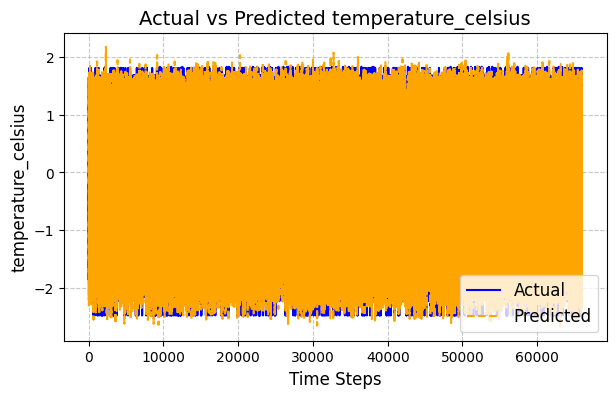

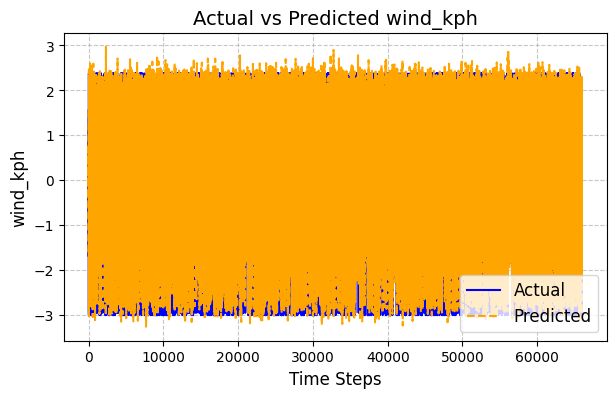

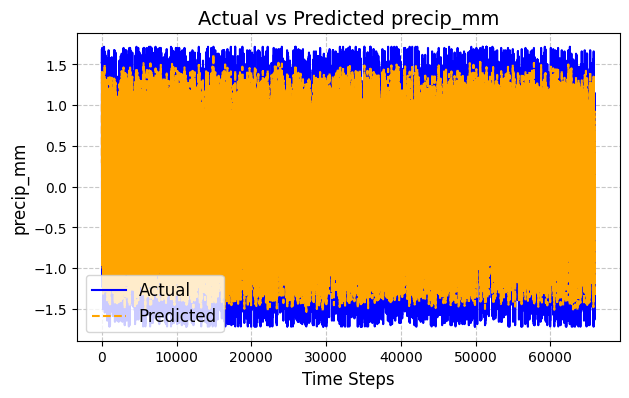

In [116]:
# Time Series Plots for Individual Parameters
for i, target in enumerate(target_names):
    plt.figure(figsize=(7, 4))
    plt.plot(y_test_reshaped[:, i], label='Actual', color='blue', linewidth=1.5)
    plt.plot(y_pred_reshaped[:, i], label='Predicted', color='orange', linestyle='--', linewidth=1.5)
    plt.title(f'Actual vs Predicted {target}', fontsize=14)
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel(target, fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

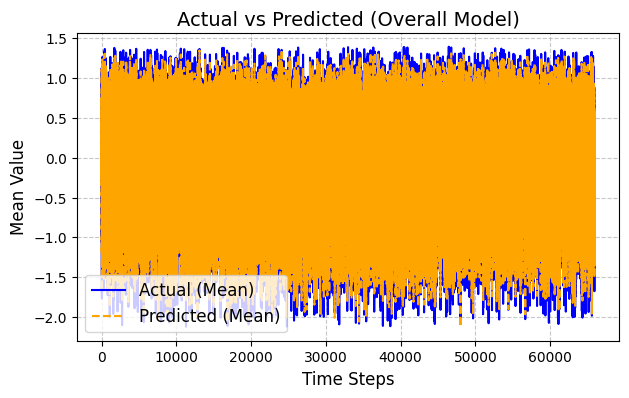

In [117]:
# Time Series Plot for Overall Model
mean_actual = np.mean(y_test_reshaped, axis=1)
mean_predicted = np.mean(y_pred_reshaped, axis=1)

plt.figure(figsize=(7, 4))
plt.plot(mean_actual, label='Actual (Mean)', color='blue', linewidth=1.5)
plt.plot(mean_predicted, label='Predicted (Mean)', color='orange', linestyle='--', linewidth=1.5)
plt.title('Actual vs Predicted (Overall Model)', fontsize=14)
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Mean Value', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

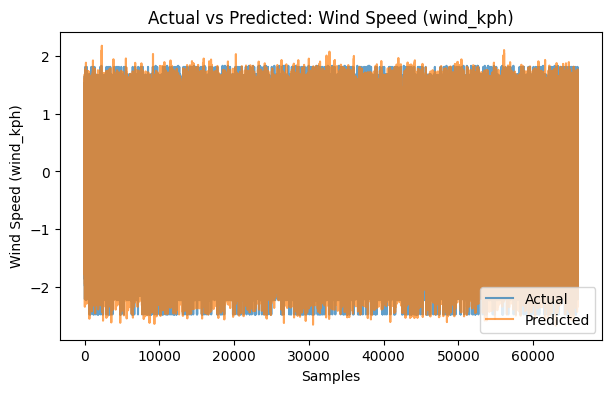

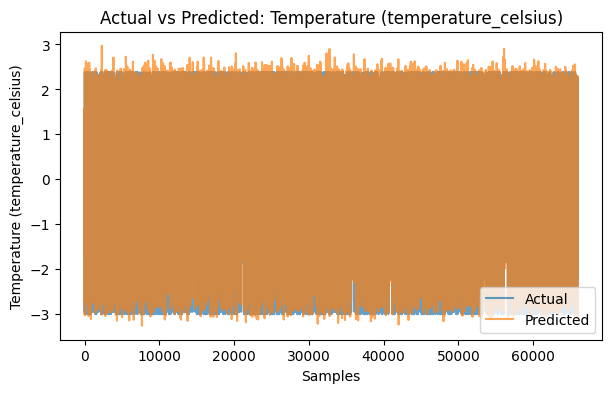

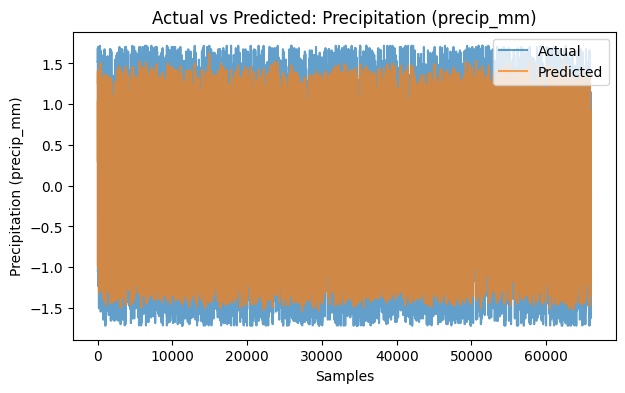

In [118]:
import matplotlib.pyplot as plt

# Define parameter names
param_names = ["Wind Speed (wind_kph)", "Temperature (temperature_celsius)", "Precipitation (precip_mm)"]

# Plot predictions vs actual values for each parameter
for i, col in enumerate(param_names):
    plt.figure(figsize=(7, 4))
    plt.plot(y_test_reshaped[:, i], label='Actual', alpha=0.7)
    plt.plot(y_pred_reshaped[:, i], label='Predicted', alpha=0.7)
    plt.title(f'Actual vs Predicted: {col}')
    plt.xlabel('Samples')
    plt.ylabel(col)
    plt.legend()
    plt.show()


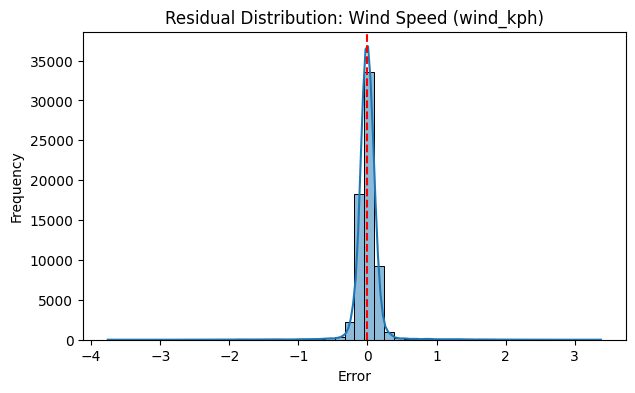

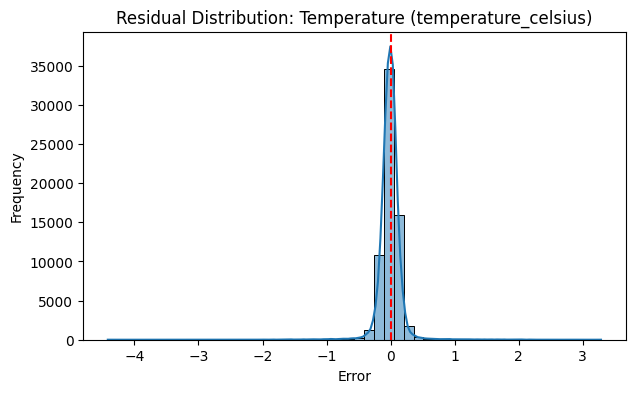

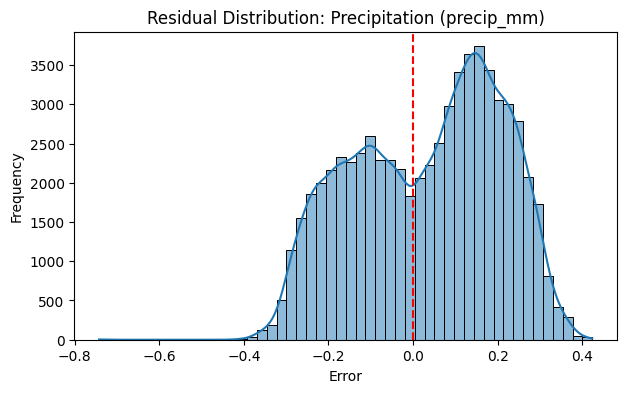

In [119]:
import seaborn as sns

# Compute residuals
residuals = y_test_reshaped - y_pred_reshaped

# Plot residual distribution for each parameter
param_names = ["Wind Speed (wind_kph)", "Temperature (temperature_celsius)", "Precipitation (precip_mm)"]

for i, col in enumerate(param_names):
    plt.figure(figsize=(7, 4))
    sns.histplot(residuals[:, i], bins=50, kde=True)
    plt.axvline(0, color='red', linestyle='dashed')  # Zero-error reference line
    plt.title(f'Residual Distribution: {col}')
    plt.xlabel('Error')
    plt.ylabel('Frequency')
    plt.show()


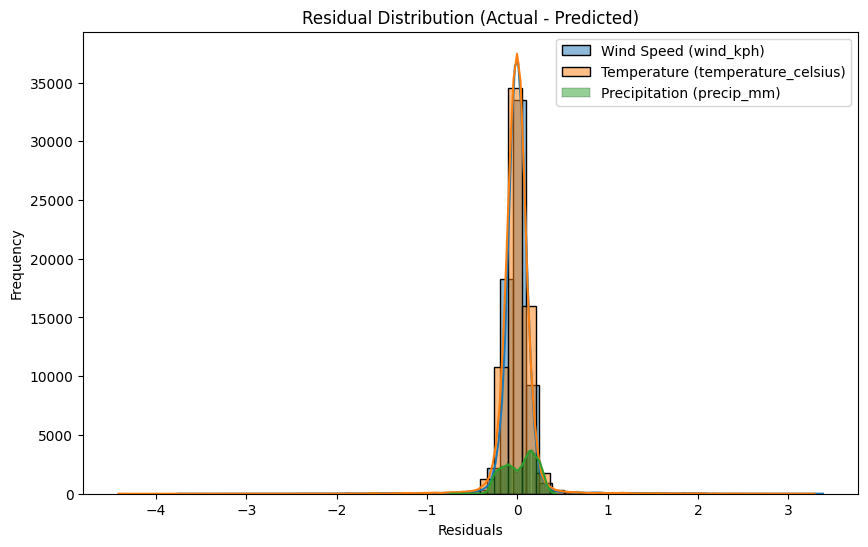

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate residuals (errors)
residuals = y_test_reshaped - y_pred_reshaped

# Plot residual distributions
plt.figure(figsize=(10, 6))
for i, col in enumerate(["Wind Speed (wind_kph)", "Temperature (temperature_celsius)", "Precipitation (precip_mm)"]):
    sns.histplot(residuals[:, i], kde=True, label=col, bins=50, alpha=0.5)

plt.title("Residual Distribution (Actual - Predicted)")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.legend()
plt.show()


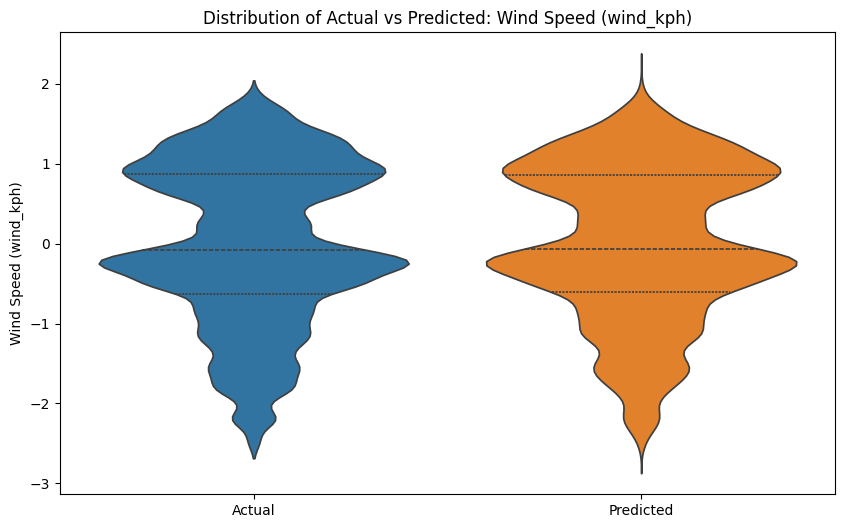

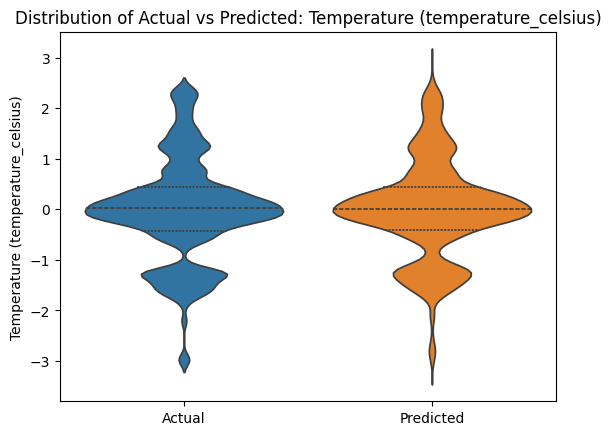

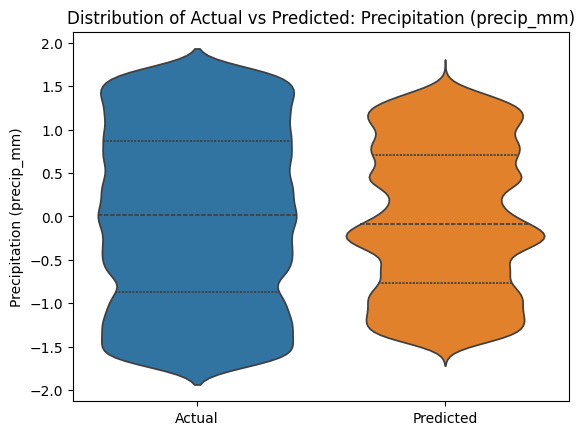

In [121]:
plt.figure(figsize=(10, 6))
for i, col in enumerate(["Wind Speed (wind_kph)", "Temperature (temperature_celsius)", "Precipitation (precip_mm)"]):
    sns.violinplot(data=[y_test_reshaped[:, i], y_pred_reshaped[:, i]], inner="quartile")
    plt.xticks([0, 1], ["Actual", "Predicted"])
    plt.title(f'Distribution of Actual vs Predicted: {col}')
    plt.ylabel(col)
    plt.show()


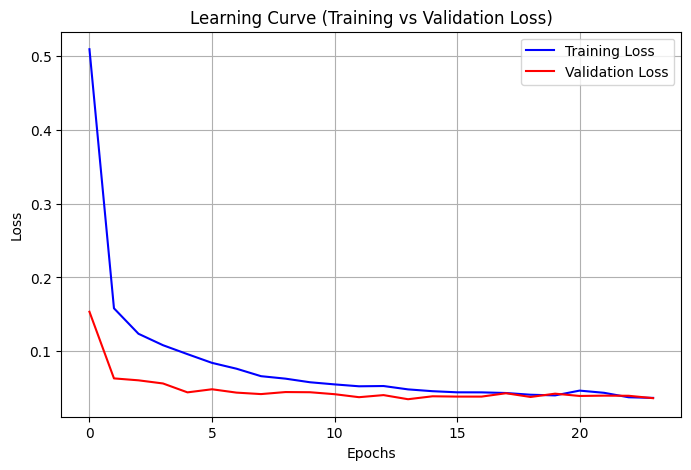

In [125]:
import matplotlib.pyplot as plt

# Assuming 'history' is the object returned by model.fit()
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')

plt.title('Learning Curve (Training vs Validation Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [126]:
def plot_overall_actual_vs_predicted(y_actual, y_pred, num_samples=5):
    """
    Plots actual vs. predicted values for all target variables in a single figure.

    Parameters:
        y_actual (numpy array): Actual values (shape: [num_samples, num_targets]).
        y_pred (numpy array): Predicted values (shape: [num_samples, num_targets]).
        num_samples (int): Number of samples to plot (default: 5).
    """
    targets = ["Wind Speed (wind_kph)", "Temperature (temperature_celsius)", "Precipitation (precip_mm)"]
    plt.figure(figsize=(10, 6))
    
    for i, target in enumerate(targets):
        plt.subplot(3, 1, i+1)
        for j in range(num_samples):
            plt.plot(y_actual[j, :, i], label=f"Actual (Sample {j+1})" if j == 0 else "", linestyle="--", marker="o", color='blue')
            plt.plot(y_pred[j, :, i], label=f"Predicted (Sample {j+1})" if j == 0 else "", linestyle="-", marker="x", color='red')
        plt.xlabel("Time Steps (Days)")
        plt.ylabel(target)
        plt.title(f"Actual vs Predicted - {target}")
        plt.legend()
        plt.grid()
    
    plt.tight_layout()
    plt.show()

In [127]:
# Reshape y_test and y_pred for overall plotting
y_actual_all = y_test  # Shape: [num_samples, pred_length, num_targets]
y_pred_all = y_pred    # Shape: [num_samples, pred_length, num_targets]

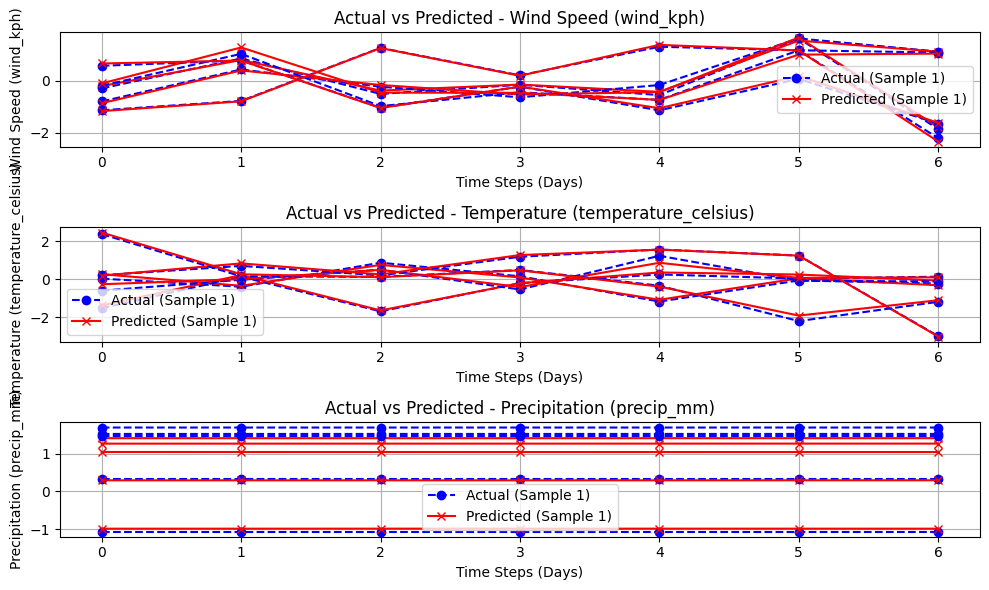

In [128]:
# Generate the overall plot
plot_overall_actual_vs_predicted(y_actual_all, y_pred_all, num_samples=5)

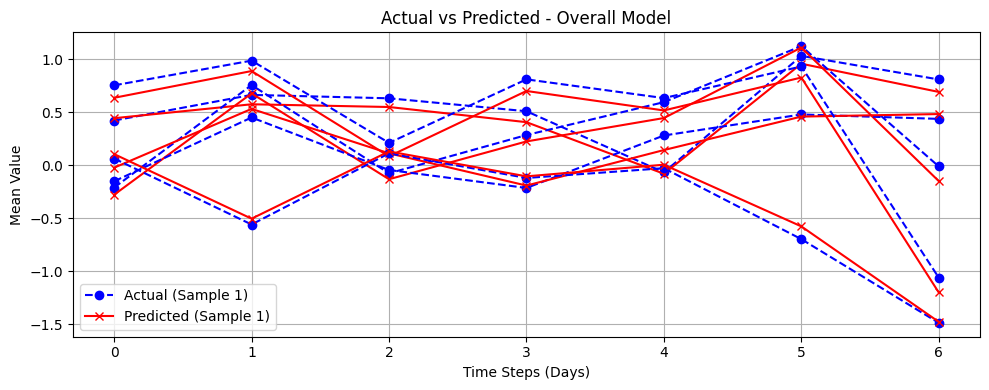

In [129]:
# Compute mean actual and predicted values
mean_actual = np.mean(y_actual_all, axis=2)  # Shape: [num_samples, pred_length]
mean_predicted = np.mean(y_pred_all, axis=2)  # Shape: [num_samples, pred_length]

# Plot for overall model
plt.figure(figsize=(10, 4))
for j in range(5):  # Plot first 5 samples
    plt.plot(mean_actual[j], label=f"Actual (Sample {j+1})" if j == 0 else "", linestyle="--", marker="o", color='blue')
    plt.plot(mean_predicted[j], label=f"Predicted (Sample {j+1})" if j == 0 else "", linestyle="-", marker="x", color='red')
plt.xlabel("Time Steps (Days)")
plt.ylabel("Mean Value")
plt.title("Actual vs Predicted - Overall Model")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()